# Extração dos dados

#### Importando biblioteca

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

# Scikit-learn imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score, accuracy_score

#### Importando a base

In [ ]:
extracao_automatica = True

try:
    print("Tentando carregar a base consolidada via Parquet...")
    df = pd.read_parquet('https://drive.google.com/uc?export=download&id=1STRXyZWw5lYOjhNJ-nSEQrOXu-r_OwGs')
    print("Sucesso! Base Parquet carregada.")
except Exception as e:
    print(f"Aviso: Não foi possível carregar o Parquet ({e}). Ativando extração manual por tabelas...")
    extracao_automatica = False

Tentando carregar a base consolidada via Parquet...
Sucesso! Base Parquet carregada.


In [ ]:
if not extracao_automatica:
  # ── Mapa: nome da variável → URL ──────────────────────────────────────
  URLS = {
      "tb_vendedores"     : "https://drive.google.com/uc?export=download&id=1k0ezAhw8nfago2KPDzmDO9Uwly8qFaqu",
      "tb_avaliacoes"     : "https://drive.google.com/uc?export=download&id=1hNL3ITSx6tNnnrYJ98t_l-qs4QAfHhIM",
      "tb_itens_pedidos"  : "https://drive.google.com/uc?export=download&id=1g1yAAJTLAcUTfwIlr4P9bgyHmyUniDFE",
      "tb_pagamento"      : "https://drive.google.com/uc?export=download&id=1KNWfkkJk3OgRbrfGFqLG0IVwaqpAvgZU",
      "tb_auxiliar"       : "https://drive.google.com/uc?export=download&id=1CQthIFVvieuko0GpavX1dyTWpvDJIjvB",
      "tb_pedidos"        : "https://drive.google.com/uc?export=download&id=15_BvQJV5Hoo8LgB2T9pB0uWlc5mgo40m",
      "tb_produtos"       : "https://drive.google.com/uc?export=download&id=10B9WW6eFeOfSIr6LI5RVYl7MKpzc6Umc",
      "tb_clientes"       : "https://drive.google.com/uc?export=download&id=1a1UCw5u0joBFy6ZkQLYYOLBIl6O-IaId",
      "tb_geolocalizacao" : "https://drive.google.com/uc?export=download&id=10BH98NRpnt4v7iNLH_HjDKVtXpTQhTsa",
  }

  # ── Carrega todas de uma vez num dicionário ───────────────────────────
  dfs = {nome: pd.read_csv(url) for nome, url in URLS.items()}

  # ── Desempacota cada uma numa variável individual (como antes) ────────
  tb_vendedores, tb_avaliacoes, tb_itens_pedidos, tb_pagamento, tb_auxiliar,tb_pedidos, tb_produtos, tb_clientes, tb_geolocalizacao = dfs.values()

#### Renomeando as colunas

In [ ]:
if not extracao_automatica:
  RENAME = {
      "tb_vendedores": {
          "seller_id"              : "id_vendedor",
          "seller_zip_code_prefix" : "cep_prefixo_vendedor",
          "seller_city"            : "cidade_vendedor",
          "seller_state"           : "estado_vendedor",
      },
      "tb_avaliacoes": {
          "review_id"                : "id_avaliacao",
          "order_id"                 : "id_pedido",
          "review_score"             : "nota_avaliacao",
          "review_comment_title"     : "titulo_comentario",
          "review_comment_message"   : "mensagem_comentario",
          "review_creation_date"     : "data_criacao_avaliacao",
          "review_answer_timestamp"  : "data_resposta_avaliacao",
      },
      "tb_itens_pedidos": {
          "order_id"            : "id_pedido",
          "order_item_id"       : "id_item_pedido",
          "product_id"          : "id_produto",
          "seller_id"           : "id_vendedor",
          "shipping_limit_date" : "prazo_envio",
          "price"               : "preco",
          "freight_value"       : "valor_frete",
      },
      "tb_pagamento": {
          "order_id"             : "id_pedido",
          "payment_sequential"   : "sequencia_pagamento",
          "payment_type"         : "tipo_pagamento",
          "payment_installments" : "parcelas",
          "payment_value"        : "valor_pagamento",
      },
      "tb_pedidos": {
          "order_id"                       : "id_pedido",
          "customer_id"                    : "id_cliente",
          "order_status"                   : "status_pedido",
          "order_purchase_timestamp"       : "data_compra",
          "order_approved_at"              : "data_aprovacao",
          "order_delivered_carrier_date"   : "data_entrega_transportadora",
          "order_delivered_customer_date"  : "data_entrega_cliente",
          "order_estimated_delivery_date"  : "data_estimada_entrega",
      },
      "tb_produtos": {
          "product_id"                : "id_produto",
          "product_category_name"     : "categoria_produto",
          "product_name_lenght"       : "tamanho_nome_produto",
          "product_description_lenght": "tamanho_descricao_produto",
          "product_photos_qty"        : "qtd_fotos_produto",
          "product_weight_g"          : "peso_g",
          "product_length_cm"         : "comprimento_cm",
          "product_height_cm"         : "altura_cm",
          "product_width_cm"          : "largura_cm",
      },
      "tb_clientes": {
          "customer_id"              : "id_cliente",
          "customer_unique_id"       : "id_unico_cliente",
          "customer_zip_code_prefix" : "cep_prefixo_cliente",
          "customer_city"            : "cidade_cliente",
          "customer_state"           : "estado_cliente",
      },
      "tb_geolocalizacao": {
          "geolocation_zip_code_prefix" : "cep_prefixo",
          "geolocation_lat"             : "latitude",
          "geolocation_lng"             : "longitude",
          "geolocation_city"            : "cidade",
          "geolocation_state"           : "estado",
      },
  }

  # ── Aplicar renomeação em todas as tabelas de uma vez ─────────────────
  for nome, df in dfs.items():
      if nome in RENAME:
          dfs[nome] = df.rename(columns=RENAME[nome])

  # Desempacota novamente com nomes já em PT
  tb_vendedores, tb_avaliacoes, tb_itens_pedidos, tb_pagamento, tb_auxiliar, \
  tb_pedidos, tb_produtos, tb_clientes, tb_geolocalizacao = dfs.values()

# Tratamento dos dados

#### Realizando a tipificação dos dados

In [ ]:
if not extracao_automatica:
  SCHEMA = {
      "tb_itens_pedidos": {
          "datetime" : ["prazo_envio"],
          "string"   : ["id_pedido", "id_produto", "id_vendedor"],
          "float32"  : ["preco", "valor_frete"],
          "Int8"     : ["id_item_pedido"],
      },
      "tb_pedidos": {
          "datetime" : ["data_compra", "data_aprovacao",
                        "data_entrega_transportadora",
                        "data_entrega_cliente", "data_estimada_entrega"],
          "string"   : ["id_pedido", "id_cliente", "status_pedido"],
      },
      "tb_produtos": {
          "string"   : ["id_produto", "categoria_produto"],
          "float32"  : ["peso_g", "comprimento_cm", "altura_cm", "largura_cm"],
          "Int16"    : ["tamanho_nome_produto", "tamanho_descricao_produto",
                        "qtd_fotos_produto"],
      },
      "tb_avaliacoes": {
          "datetime" : ["data_criacao_avaliacao", "data_resposta_avaliacao"],
          "string"   : ["id_avaliacao", "id_pedido",
                        "titulo_comentario", "mensagem_comentario"],
          "Int8"     : ["nota_avaliacao"],
      },
      "tb_pagamento": {
          "string"   : ["id_pedido", "tipo_pagamento"],
          "float32"  : ["valor_pagamento"],
          "Int8"     : ["sequencia_pagamento", "parcelas"],
      },
      "tb_clientes": {
          "string"   : ["id_cliente", "id_unico_cliente",
                        "cidade_cliente", "estado_cliente"],
          "Int32"    : ["cep_prefixo_cliente"],
      },
      "tb_vendedores": {
          "string"   : ["id_vendedor", "cidade_vendedor", "estado_vendedor"],
          "Int32"    : ["cep_prefixo_vendedor"],
      },
  }

##### Aplicando o SCHEMA em todas as tabelas

In [ ]:
if not extracao_automatica:
  for nome, regras in SCHEMA.items():
      df_alvo = dfs[nome]
      for dtype, colunas in regras.items():
          cols_existentes = [c for c in colunas if c in df_alvo.columns]
          if dtype == "datetime":
              for col in cols_existentes:
                  df_alvo[col] = pd.to_datetime(df_alvo[col])
          else:
              df_alvo[cols_existentes] = df_alvo[cols_existentes].astype(dtype)
      dfs[nome] = df_alvo

  # Desempacota com tipos já aplicados
  tb_vendedores, tb_avaliacoes, tb_itens_pedidos, tb_pagamento, tb_auxiliar, \
  tb_pedidos, tb_produtos, tb_clientes, tb_geolocalizacao = dfs.values()

  # ── Verificação rápida ─────────────────────────────────────────────────────
  for nome, df_alvo in dfs.items():
      mem = df_alvo.memory_usage(deep=True).sum() / 1024**2
      print(f"{nome:<22} → {df_alvo.shape}  |  {mem:.1f} MB")

#### Realizando a junção das tabelas

In [ ]:
if not extracao_automatica:
  tb_pedidos = tb_pedidos[['id_pedido', 'data_compra', 'data_entrega_transportadora','data_entrega_cliente', 'data_estimada_entrega']]
  tb_produtos = tb_produtos[['id_produto', 'categoria_produto']]
  tb_itens_pedidos = tb_itens_pedidos[['id_pedido', 'id_produto', 'prazo_envio', 'preco', 'valor_frete']]

In [ ]:
if not extracao_automatica:
  df = tb_pedidos.merge(tb_itens_pedidos, how='left', on='id_pedido')
  df = df.merge(tb_produtos, how='left', on='id_produto')
  df = df.merge(tb_avaliacoes, how='left', on='id_pedido')
  df.head()

In [ ]:
if not extracao_automatica:
  # 1. Verificar o impacto geral no DataFrame
  total_linhas = len(df)
  pedidos_unicos = df['id_pedido'].nunique()

  print(f"Total de linhas atual: {total_linhas}")
  print(f"Total de pedidos únicos: {pedidos_unicos}")
  print(f"Diferença (linhas extras geradas): {total_linhas - pedidos_unicos}")

  # 2. Contar quantas linhas estão 100% duplicadas (todas as colunas iguais)
  duplicatas_exatas = df.duplicated().sum()
  print(f"Linhas 100% idênticas: {duplicatas_exatas}")

  # 3. Contar quantas vezes CADA pedido se repetiu
  contagem_pedidos = df['id_pedido'].value_counts()
  print("\nTop 5 pedidos mais repetidos:")
  print(contagem_pedidos.head())

  # 4. Visualizar o problema na prática
  # Vamos filtrar o DataFrame para mostrar apenas um dos pedidos que mais se multiplicou
  pedido_problematico = contagem_pedidos.index[0] # Pega o ID do pedido que mais repetiu
  display(df[df['id_pedido'] == pedido_problematico].head())

In [ ]:
if not extracao_automatica:
  df = df.drop_duplicates(['id_avaliacao'])

In [ ]:
if not extracao_automatica:
  # 1. Verificar o impacto geral no DataFrame
  total_linhas = len(df)
  pedidos_unicos = df['id_pedido'].nunique()

  print(f"Total de linhas atual: {total_linhas}")
  print(f"Total de pedidos únicos: {pedidos_unicos}")
  print(f"Diferença (linhas extras geradas): {total_linhas - pedidos_unicos}")

  # 2. Contar quantas linhas estão 100% duplicadas (todas as colunas iguais)
  duplicatas_exatas = df.duplicated().sum()
  print(f"Linhas 100% idênticas: {duplicatas_exatas}")

#### Gerando novas colunas

| Coluna | Pergunta / Descrição |
| :--- | :--- |
| `dias_para_entrega` | Quanto tempo o cliente esperou no total? |
| `dias_ate_transportadora` | O vendedor demorou para despachar? |
| `dias_transportadora_cliente` | A transportadora demorou após receber? |
| `desvio_previsao_dias` | A previsão foi cumprida? Por quantos dias errou? |
| `entregue_no_prazo` | Booleano direto para filtros e agrupamentos |
| `fator_extraordinario` | Pedidos com atraso estatisticamente anormal (outliers reais) |

In [ ]:
if not extracao_automatica:
  # ── 1. Tempo total de entrega ao cliente (dias corridos) ──────────────────
  df['dias_para_entrega'] = (
      df['data_entrega_cliente'] - df['data_compra']
  ).dt.days

  # ── 2. Tempo do vendedor até a transportadora ─────────────────────────────
  df['dias_ate_transportadora'] = (
      df['data_entrega_transportadora'] - df['data_compra']
  ).dt.days

  # ── 3. Tempo da transportadora até o cliente ──────────────────────────────
  df['dias_transportadora_cliente'] = (
      df['data_entrega_cliente'] - df['data_entrega_transportadora']
  ).dt.days

  # ── 4. Diferença entre entrega real e previsão (+ = atraso, - = adiantado)
  df['desvio_previsao_dias'] = (
      df['data_entrega_cliente'] - df['data_estimada_entrega']
  ).dt.days

  # ── 5. Flag: entregue dentro do prazo? ────────────────────────────────────
  df['entregue_no_prazo'] = df['desvio_previsao_dias'] <= 0

  # ── 6. Fator extraordinário: desvio acima de 2 desvios-padrão ────────────
  media  = df['desvio_previsao_dias'].mean()
  desvio = df['desvio_previsao_dias'].std()

  df['fator_extraordinario'] = df['desvio_previsao_dias'] > (media + 2 * desvio)

  # ── Resumo rápido ─────────────────────────────────────────────────────────
  print("=== Pontualidade ===")
  print(df['entregue_no_prazo'].value_counts(normalize=True).map('{:.1%}'.format))

  print("\n=== Desvio da previsão (dias) ===")
  print(df['desvio_previsao_dias'].describe().round(1))

  print("\n=== Casos com fator extraordinário ===")
  print(f"{df['fator_extraordinario'].sum():,} pedidos  "
        f"({df['fator_extraordinario'].mean():.1%} do total)")

#### Refinando os dados vazios

In [ ]:
display(df.head())

,data_compra,data_entrega_transportadora,data_entrega_cliente,data_estimada_entrega,prazo_envio,preco,valor_frete,categoria_produto,nota_avaliacao,titulo_comentario,mensagem_comentario,data_criacao_avaliacao,data_resposta_avaliacao,dias_para_entrega,dias_ate_transportadora,dias_transportadora_cliente,desvio_previsao_dias,entregue_no_prazo,fator_extraordinario
0,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-06 11:07:15,29.990000,8.720000,utilidades_domesticas,4,<NA>,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,8.0,2.0,6.0,-8.0,True,False
1,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-30 03:24:27,118.699997,22.760000,perfumaria,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,13.0,1.0,12.0,-6.0,True,False
2,2018-08-08 08:38:49,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-13 08:55:23,159.899994,19.219999,automotivo,5,<NA>,<NA>,2018-08-18,2018-08-22 19:07:58,9.0,0.0,9.0,-18.0,True,False
3,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-23 19:45:59,45.000000,27.200001,pet_shop,5,<NA>,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58,13.0,3.0,9.0,-13.0,True,False
4,2018-02-13 21:18:39,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02-19 20:31:37,19.900000,8.720000,papelaria,5,<NA>,<NA>,2018-02-17,2018-02-18 13:02:51,2.0,0.0,1.0,-10.0,True,False


Antes de focar nas varíaveis principais, iremos eliminar os IDs que podem confundir nosso modelo posteriormente

In [ ]:
if not extracao_automatica:
  # Lista com os nomes exatos das colunas de ID que não agregam valor preditivo
  colunas_para_remover = ['id_pedido', 'id_produto', 'id_avaliacao']

  df = df.drop(columns=colunas_para_remover)

  print(f"Foram removidas {len(colunas_para_remover)} colunas.")

In [ ]:
if not extracao_automatica:
  # ==========================================
  # 1. VISÃO GERAL: QUAIS COLUNAS TÊM VAZIOS E QUAL A PORCENTAGEM?
  # ==========================================

  # Calcula o total de nulos e o percentual em relação ao tamanho do dataframe
  total_linhas = len(df)
  nulos_totais = df.isnull().sum()
  nulos_percentual = (nulos_totais / total_linhas) * 100

  # Cria uma tabela resumo bonita para visualização
  resumo_nulos = pd.DataFrame({
      'Total_Vazio': nulos_totais,
      '%_do_Total': nulos_percentual.round(2) # Arredondando para 2 casas decimais
  })

  # Filtra para mostrar APENAS as colunas que têm algum dado faltandof
  resumo_nulos = resumo_nulos[resumo_nulos['Total_Vazio'] > 0].sort_values(by='%_do_Total', ascending=False)

  print("--- VISÃO GERAL DE DADOS FALTANTES ---")
  print("Base de Dados: df_s_comentario")
  if resumo_nulos.empty:
      print("Nenhum valor nulo encontrado no DataFrame!")
  else:
      display(resumo_nulos)

Visto que nosso modelo focará na análise da nota e que as colunas de título e comentário podem ser as mais importantes, iremos realizar um tratamento especial

In [ ]:
if not extracao_automatica:
  # ==========================================
  # 2. LUPA NOS COMENTÁRIOS: NULOS E STRINGS VAZIAS
  # ==========================================
  # Assumindo que a coluna continua se chamando 'mensagem_comentario'
  coluna_txt = 'mensagem_comentario'

  # A) Contando os nulos reais (NaN)
  qtd_nulos = df[coluna_txt].isnull().sum()

  # B) Contando strings vazias ou preenchidas apenas com espaços (ex: "   ")
  # Usamos .astype(str) para garantir que tudo é texto, e .str.strip() para arrancar espaços extras
  qtd_em_branco = df[df[coluna_txt].fillna('x').astype(str).str.strip() == ''].shape[0]

  total_sem_texto = qtd_nulos + qtd_em_branco
  percentual_sem_texto = (total_sem_texto / total_linhas) * 100

  print(f"\n--- ANÁLISE DA COLUNA '{coluna_txt}' ---")
  print(f"Total de registros na base: {total_linhas}")
  print(f"Comentários Nulos (NaN): {qtd_nulos}")
  print(f"Comentários em Branco (só espaços): {qtd_em_branco}")
  print(f"Total de registros SEM comentário: {total_sem_texto} ({percentual_sem_texto:.2f}% da base)")

Em comentários que há o título mas não há comentário, simplesmente copiamos o título para o campo

In [ ]:
if not extracao_automatica:
  nulos_antes = df['mensagem_comentario'].isnull().sum()
  print(f"Mensagens vazias antes de realizar o truque com o título: {nulos_antes}")

In [ ]:
if not extracao_automatica:
  df_c_com_neutro = df.copy()

In [ ]:
if not extracao_automatica:
  df_c_com_neutro = df_c_com_neutro.dropna(subset=['nota_avaliacao'])

In [ ]:
if not extracao_automatica:
  # 1. Padronizando: Transforma qualquer string vazia ou só com espaços ("   ") em nulo (NaN) de verdade
  df_c_com_neutro['mensagem_comentario'] = df_c_com_neutro['mensagem_comentario'].replace(r'^\s*$', np.nan, regex=True)
  df_c_com_neutro['titulo_comentario'] = df_c_com_neutro['titulo_comentario'].replace(r'^\s*$', np.nan, regex=True)

  # 2. A CONDICIONAL DE IMPUTAÇÃO
  # O método .fillna() preenche os "NaN" da mensagem puxando a informação do título.
  # Se a mensagem já existir, ele não faz nada (mantém a mensagem original).
  df_c_com_neutro['mensagem_comentario'] = df_c_com_neutro['mensagem_comentario'].fillna(df['titulo_comentario'])

In [ ]:
if not extracao_automatica:
  # Vamos ver quantas linhas conseguimos salvar!
  nulos_depois = df_c_com_neutro['mensagem_comentario'].isnull().sum()
  linhas_salvas = nulos_antes - nulos_depois

  print(f"Mensagens vazias depois da imputação: {nulos_depois}")
  print(f"Recuperamos {linhas_salvas} avaliações usando o título!")

Agora, em comentários que só resta a nota sem comentários e títulos iremos fazer com que o modelo trate com neutralidade

In [ ]:
if not extracao_automatica:
  df_c_com_neutro['mensagem_comentario'] = df_c_com_neutro['mensagem_comentario'].fillna("sem comentario")

In [ ]:
if not extracao_automatica:
  # Vamos ver quantas linhas conseguimos salvar!
  nulos_depois = df_c_com_neutro['mensagem_comentario'].isnull().sum()
  print(f"Mensagens vazias depois da imputação: {nulos_depois}")

#### Realizando o salvamento dos dados

In [ ]:
if not extracao_automatica:
  df = df.reset_index(drop=True)
  df.to_parquet('df_tratado.parquet', index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98411 entries, 0 to 98410
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   data_compra                  98411 non-null  datetime64[ns]
 1   data_entrega_transportadora  96698 non-null  datetime64[ns]
 2   data_entrega_cliente         95602 non-null  datetime64[ns]
 3   data_estimada_entrega        98411 non-null  datetime64[ns]
 4   prazo_envio                  97685 non-null  datetime64[ns]
 5   preco                        97685 non-null  float32       
 6   valor_frete                  97685 non-null  float32       
 7   categoria_produto            96284 non-null  string        
 8   nota_avaliacao               98410 non-null  Int8          
 9   titulo_comentario            11519 non-null  string        
 10  mensagem_comentario          40668 non-null  string        
 11  data_criacao_avaliacao       98410 non-nu

# Análise dos dados

# Modelos de Análise Sentimental
Três modelos foram testados e validados conforme requerimentos

In [ ]:
# Criando uma cópia que não possui comentários nulos (sobra, em torno de 48 mil linhas)
df_s_comentario = df.dropna(subset=['mensagem_comentario']).copy()

## Vader
Modelo de análise sentimental com regras de matemáticas

#### Criando a análise sentimental do comentário

##### Criando a nova coluna de peso sentimental
Isto são "traduções numéricas" para os comentários de -1 a 1

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [ ]:
# Garantindo o download do dicionário do VADER
nltk.download('vader_lexicon')

# Inicializando o analisador do VADER
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
def extrair_vader_e_pesos(texto):
    if pd.isna(texto) or str(texto).strip() == "":
        return 3, 0.0  # Padrão neutro (3 para nota, 0.0 para peso sentimental)

    # 1. Extração dos pesos sentimentais puros do modelo
    scores = sia.polarity_scores(str(texto))
    compound = scores['compound']

    nota_normalizada = 3 + (2 * compound)

    # Arredonda para o inteiro mais próximo e garante o limite rígido entre 1 e 5
    nota_final = int(np.clip(round(nota_normalizada), 1, 5))

    return nota_final, compound

In [ ]:
# 3. Aplicando a função e gerando as 4 novas colunas simultaneamente
df_s_comentario[['nota_vader', 'peso_sentimental']] = df_s_comentario['mensagem_comentario'].apply(
    lambda x: pd.Series(extrair_vader_e_pesos(x))
)
df_s_comentario['peso_sentimental'] = df_s_comentario['peso_sentimental'].astype(float)

In [ ]:
display(df_s_comentario.head())

,data_compra,data_entrega_transportadora,data_entrega_cliente,data_estimada_entrega,prazo_envio,preco,valor_frete,categoria_produto,nota_avaliacao,titulo_comentario,...,data_criacao_avaliacao,data_resposta_avaliacao,dias_para_entrega,dias_ate_transportadora,dias_transportadora_cliente,desvio_previsao_dias,entregue_no_prazo,fator_extraordinario,nota_vader,peso_sentimental
0,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-06 11:07:15,29.990000,8.720000,utilidades_domesticas,4,<NA>,...,2017-10-11,2017-10-12 03:43:48,8.0,2.0,6.0,-8.0,True,False,3.0,0.000
1,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-30 03:24:27,118.699997,22.760000,perfumaria,4,Muito boa a loja,...,2018-08-08,2018-08-08 18:37:50,13.0,1.0,12.0,-6.0,True,False,3.0,0.000
3,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-23 19:45:59,45.000000,27.200001,pet_shop,5,<NA>,...,2017-12-03,2017-12-05 19:21:58,13.0,3.0,9.0,-13.0,True,False,2.0,-0.296
6,2017-04-11 12:22:08,NaT,NaT,2017-05-09,2017-04-19 13:25:17,49.900002,16.049999,<NA>,2,<NA>,...,2017-05-13,2017-05-13 20:25:42,NaN,NaN,NaN,NaN,False,False,3.0,0.000
10,2017-05-16 19:41:10,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,2017-05-22 19:50:18,99.000000,30.530001,ferramentas_jardim,1,<NA>,...,2017-05-30,2017-05-30 23:13:47,12.0,1.0,10.0,-9.0,True,False,3.0,0.000


#### Avaliando nota atribuída pelo Vader

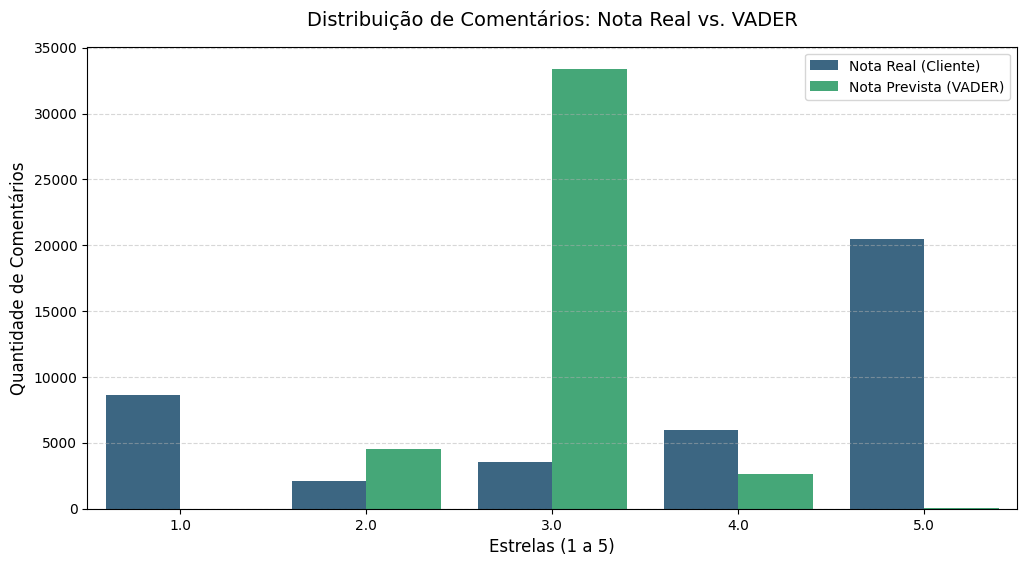

In [ ]:
# 1. Preparando os dados
df_plot = df_s_comentario[['nota_avaliacao', 'nota_vader']].melt(
    var_name='Tipo de Nota',
    value_name='Estrelas'
)

# 2. Renomeando
df_plot['Tipo de Nota'] = df_plot['Tipo de Nota'].map({
    'nota_avaliacao': 'Nota Real (Cliente)',
    'nota_vader': 'Nota Prevista (VADER)'
})

# 3. Criando o gráfico
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_plot,
    x='Estrelas',
    hue='Tipo de Nota',
    palette='viridis'
)

plt.title('Distribuição de Comentários: Nota Real vs. VADER', fontsize=14, pad=15)
plt.xlabel('Estrelas (1 a 5)', fontsize=12)
plt.ylabel('Quantidade de Comentários', fontsize=12)

# Ajustando a legenda
plt.legend(title='', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

O Vader utiliza uma biblioteca de regras da linguagem inglesa, isto o faz perder eficácia diante de comentários brasileiros e assume todos como neutro.
Exceto aqueles que possuem acentuação exagerada, uso de emojis ou palavras em inglês (estes caíram como nota 2 ou 3)

---

*Comparando o modelo diretamente com a nota dada pelo cliente*

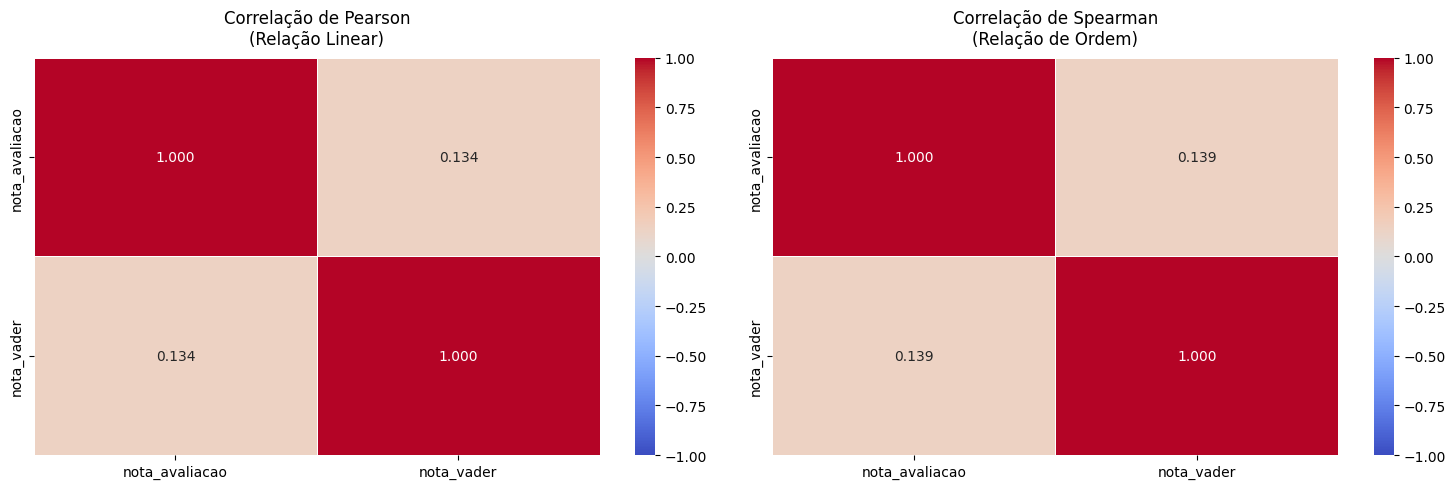

In [ ]:
# Criando um mini-dataframe só com as duas variáveis
df_correlacao = df_s_comentario[['nota_avaliacao', 'nota_vader']]

# 1. Calculando as duas matrizes de correlação
corr_pearson = df_correlacao.corr(method='pearson')
corr_spearman = df_correlacao.corr(method='spearman')

# 2. Criando a figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfico 1: Pearson (Esquerda) ---
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=axes[0] # Define que este mapa vai para o primeiro quadrado
)
axes[0].set_title('Correlação de Pearson\n(Relação Linear)', fontsize=12, pad=10)

# --- Gráfico 2: Spearman (Direita) ---
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=axes[1] # Define que este mapa vai para o segundo quadrado
)
axes[1].set_title('Correlação de Spearman\n(Relação de Ordem)', fontsize=12, pad=10)

# 3. Ajustando o espaçamento para não sobrepor os textos
plt.tight_layout()
plt.show()

Sua correlação com a varíavel original é fraquissíma pelo motivo descrito mais acima.

---

*Gerando a matriz de confusão do modelo*

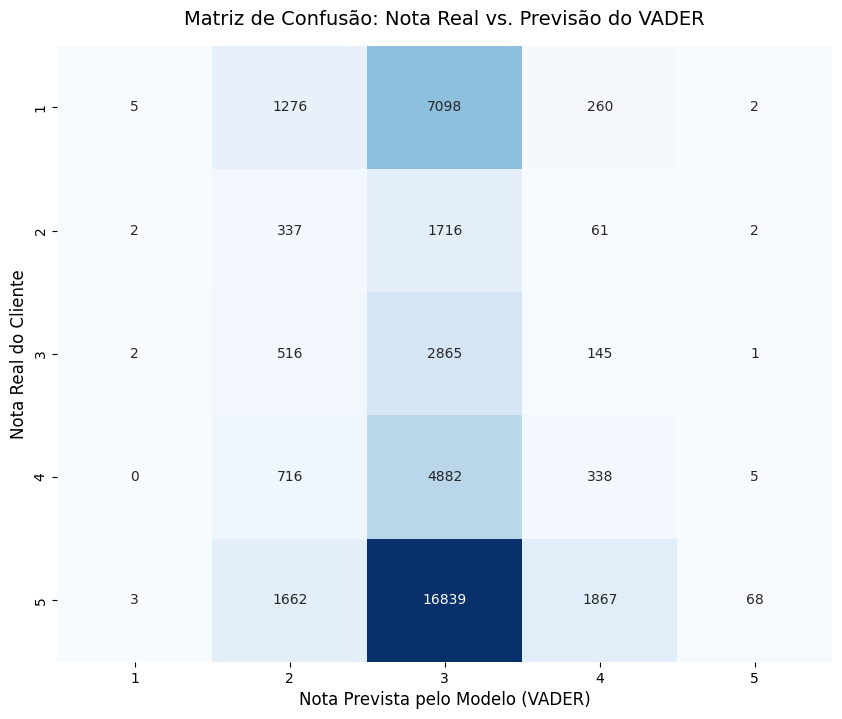

In [ ]:
# 1. Calculando a matriz de confusão
# Usamos o parâmetro labels para forçar a ordem exata das estrelas de 1 a 5 no eixo
cm = confusion_matrix(
    df_s_comentario['nota_avaliacao'],
    df_s_comentario['nota_vader'],
    labels=[1, 2, 3, 4, 5]
)

# 2. Plotando a matriz
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,        # Liga os números dentro dos quadrados
    fmt='d',           # Formata como número inteiro (sem casas decimais)
    cmap='Blues',      # Escala de cores (quanto mais azul, maior o volume)
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5],
    cbar=False         # Tira a barra de cores lateral para um visual mais limpo
)

plt.title('Matriz de Confusão: Nota Real vs. Previsão do VADER', fontsize=14, pad=15)
plt.xlabel('Nota Prevista pelo Modelo (VADER)', fontsize=12)
plt.ylabel('Nota Real do Cliente', fontsize=12)

plt.show()

Notas 5 são maioria na base de dados mas o comportamento do modelo continua sendo classificar a maioria com neutralidade.

---


## leIA
Modelo de análise sentimental voltado para linguagem portuguesa

### Análise Sentimental Inicial
Aplicando o leIA com as regras originais de treino do modelo

#### Criando a análise sentimental do comentário

##### Criando a nova coluna de peso sentimental
Isto são "traduções numéricas" para os comentários de -1 a 1

In [ ]:
!pip install leIA-br

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
# Biblioteca brasileira para NLP
from LeIA import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

In [ ]:
def calcular_peso_leia(texto):
    if pd.isna(texto):
        return 0.0
    resultado = analyzer.polarity_scores(str(texto))
    return resultado['compound']

In [ ]:
df_s_comentario['peso_sentimental_leIA'] = df_s_comentario['mensagem_comentario'].apply(calcular_peso_leia)

In [ ]:
# Coluna 1: O Peso Numérico (-1 a 1)
# O .apply() vai rodar a nossa função linha por linha na coluna de mensagens
df_s_comentario['peso_sentimental_leIA'] = df_s_comentario['mensagem_comentario'].apply(calcular_peso_leia)

# Coluna 2: A Identificação (Categoria)
# 6 pontos de corte para criar 5 intervalos
#cortes = [-1.01, -0.4, -0.05, 0.05, 0.5, 1.01]
cortes = [-1.01, -0.6, -0.1, 0.1, 0.6, 1.01]

# As categorias agora são os valores das estrelas (como números ou strings)
categorias = [1, 2, 3, 4, 5]

df_s_comentario['nota_leIA'] = pd.cut(
    df_s_comentario['peso_sentimental_leIA'],
    bins=cortes,
    labels=categorias,
    include_lowest=True
)
df_s_comentario['nota_leIA'] = df_s_comentario['nota_leIA'].astype(float)

In [ ]:
display(df_s_comentario.head())

,data_compra,data_entrega_transportadora,data_entrega_cliente,data_estimada_entrega,prazo_envio,preco,valor_frete,categoria_produto,nota_avaliacao,titulo_comentario,...,dias_para_entrega,dias_ate_transportadora,dias_transportadora_cliente,desvio_previsao_dias,entregue_no_prazo,fator_extraordinario,nota_vader,peso_sentimental,peso_sentimental_leIA,nota_leIA
0,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-06 11:07:15,29.990000,8.720000,utilidades_domesticas,4,<NA>,...,8.0,2.0,6.0,-8.0,True,False,3.0,0.000,0.5023,4.0
1,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-30 03:24:27,118.699997,22.760000,perfumaria,4,Muito boa a loja,...,13.0,1.0,12.0,-6.0,True,False,3.0,0.000,0.4215,4.0
3,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11-23 19:45:59,45.000000,27.200001,pet_shop,5,<NA>,...,13.0,3.0,9.0,-13.0,True,False,2.0,-0.296,0.5719,4.0
6,2017-04-11 12:22:08,NaT,NaT,2017-05-09,2017-04-19 13:25:17,49.900002,16.049999,<NA>,2,<NA>,...,NaN,NaN,NaN,NaN,False,False,3.0,0.000,-0.4939,2.0
10,2017-05-16 19:41:10,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,2017-05-22 19:50:18,99.000000,30.530001,ferramentas_jardim,1,<NA>,...,12.0,1.0,10.0,-9.0,True,False,3.0,0.000,0.0000,3.0


#### Avaliando nota atribuída pelo leIA

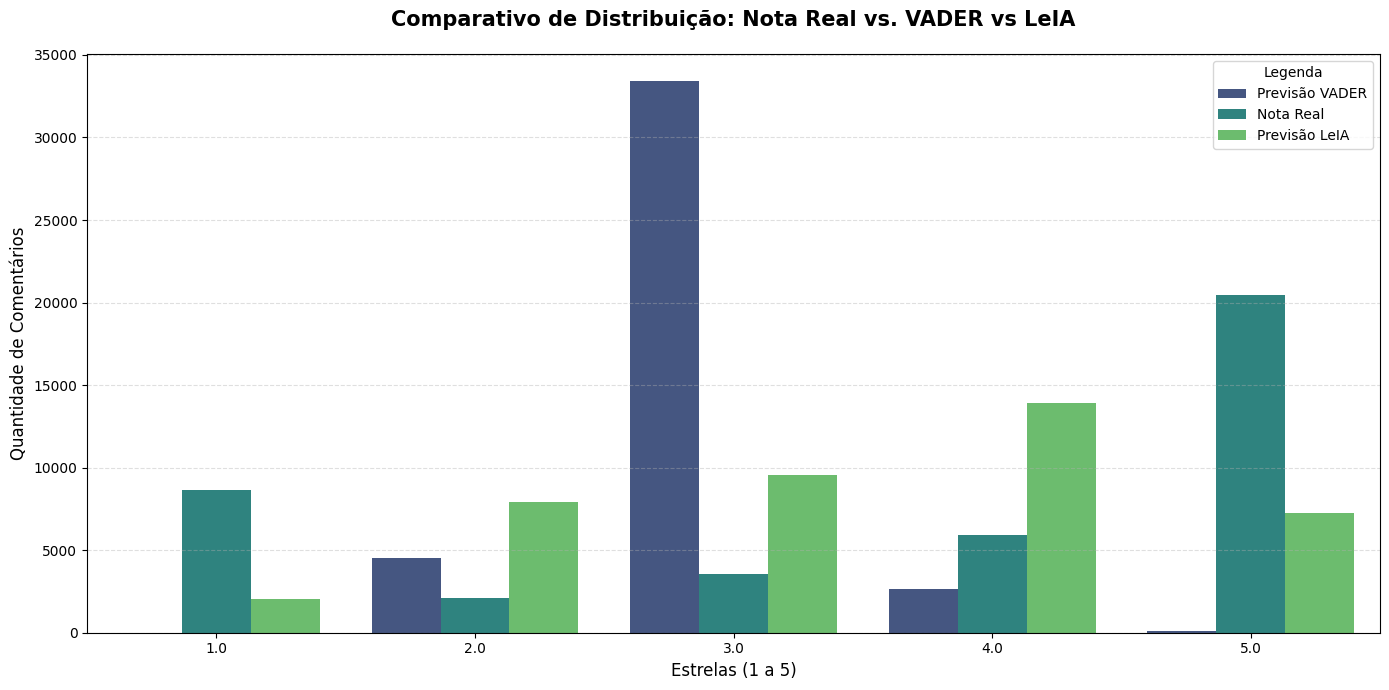

In [ ]:
# 1. Preparando os dados unificados (Derretendo as 3 colunas)
df_plot_trio = df_s_comentario[['nota_vader', 'nota_avaliacao', 'nota_leIA']].melt(
    var_name='Tipo de Nota',
    value_name='Estrelas'
)

# 2. Mapeando os nomes para a legenda ficar perfeita
df_plot_trio['Tipo de Nota'] = df_plot_trio['Tipo de Nota'].map({
    'nota_vader': 'Previsão VADER',
    'nota_avaliacao': 'Nota Real',
    'nota_leIA': 'Previsão LeIA',
})

# 3. Criando o gráfico
plt.figure(figsize=(14, 7))
sns.countplot(
    data=df_plot_trio,
    x='Estrelas',
    hue='Tipo de Nota'
    ,palette='viridis'
)

# 4. Ajustes estéticos e títulos
plt.title('Comparativo de Distribuição: Nota Real vs. VADER vs LeIA', fontsize=15, pad=20, weight='bold')
plt.xlabel('Estrelas (1 a 5)', fontsize=12)
plt.ylabel('Quantidade de Comentários', fontsize=12)

# Deixando a legenda organizada e grid leve ao fundo
plt.legend(title='Legenda', loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

O leIA é uma adaptação de regras utilizadas pelo Vader para a linguagem brasileira. O modelo tende a acertar mais a nota do cliente pelo comentário conforme as duas coolunas em verde.

---

*Vamos observar algumas notas extremas do modelo para entender sua interpretação*

In [ ]:
# Definindo uma semente
semente = 42

# 1. Isolando 3 outliers da Nota 1 (Score muito positivo)
outliers_nota1 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 1) &
    (df_s_comentario['peso_sentimental_leIA'] > 0.75)
].sample(n=3, random_state=semente)

# 2. Isolando 3 outliers da Nota 2 (Score muito positivo)
outliers_nota2 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 2) &
    (df_s_comentario['peso_sentimental_leIA'] > 0.65)
].sample(n=3, random_state=semente)

# 3. Isolando 3 outliers da Nota 4 (Score muito negativo)
outliers_nota4 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 4) &
    (df_s_comentario['peso_sentimental_leIA'] < -0.75)
].sample(n=3, random_state=semente)

# 4. Isolando 3 outliers da Nota 5 (Score muito negativo)
outliers_nota5 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 5) &
    (df_s_comentario['peso_sentimental_leIA'] < -0.60)
].sample(n=3, random_state=semente)

# Unindo os recortes em uma única tabela para leitura
amostra_outliers = pd.concat([outliers_nota1, outliers_nota2, outliers_nota4, outliers_nota5])

# Configurando o Pandas para não cortar os textos longos na tela
pd.set_option('display.max_colwidth', None)

# Exibindo o resultado da amostragem
display(amostra_outliers[['nota_avaliacao', 'nota_leIA', 'mensagem_comentario','peso_sentimental_leIA']])

# Resetando a configuração de visualização para o padrão depois da leitura
pd.reset_option('display.max_colwidth')

,nota_avaliacao,nota_leIA,mensagem_comentario,peso_sentimental_leIA
98270,1,5.0,"A carteira é linda, porém é muito grande e for a do padrão das carteiras tradicionais.",0.7906
55105,1,5.0,"Bom dia , as toalhas são de ma qualidade super finas , parece ate mais pano de chão.",0.7717
82874,1,5.0,"Chegou apenas uma peça, mas na nota e na garantia constam as duas joias.",0.7579
282,2,5.0,"tenho outro sling de outra marca com tecido muito mais macio, maleável e agradável",0.6908
1801,2,5.0,"A colcha é bonita, o tecido é fino, fácil de secar. o acabamento das almofadas menores não é legal, porque ficam apertadas.",0.6597
69760,2,5.0,"Recebi fora do prazo, mas em bom funcionamento! O produto é um pouco barulhento, porém gela rapidamente!",0.8669
69145,4,1.0,"Comprei 2 rolos de cabo 4mm e até agora so recebi 1, achei estranho porque na nota fiscal veio constando 2 e so recebi 1. Espero não ter dor de cabeça. Nao vou recmendar a loja ate resolver a situaçao",-0.7717
41640,4,1.0,"O produto veio com indícios de uso, faltando cabo RCA, adaptador para fixação no para choque e broca para furar o para choque",-0.7906
48107,4,1.0,"Somente uma SURPRESA: o produto não é americano, mas, CHINÊS. Pela qualidade e semelhança não é FALSO. Porém também não é autentico. Vou usa-lo, espero que não parta o encaixe plástico prá não travar!",-0.9471
14367,5,1.0,"Amei o produto! Veio do jeito que esperávamos, porém o correio deixou a desejar! Duas vezes não esperou descer para fazer a entrega, obrigando a ir buscar na agência! Uma falta de respeito!",-0.6083


É possível observar que o modelo confunde comentários com mais de uma afirmação. Ele não consegue lidar bem com ponderações que deveriam ser jogadas ao neutro apesar de ser melhor que o VADER.

---

*Comparando o modelo diretamente com a nota dada pelo cliente*

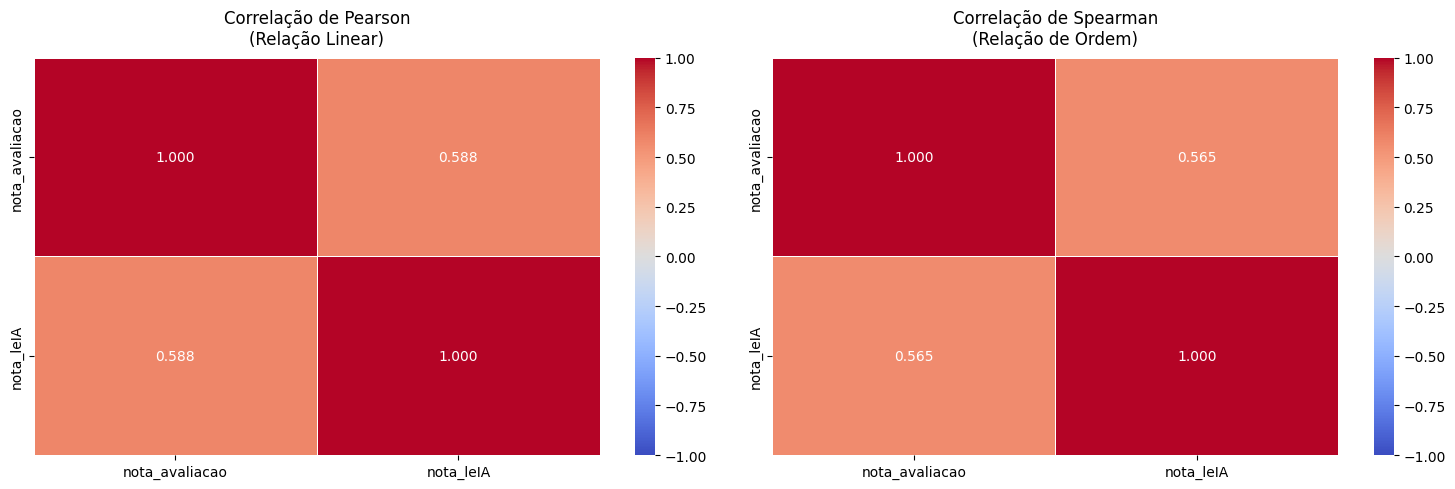

In [ ]:
# Criando um mini-dataframe só com as duas variáveis
df_correlacao = df_s_comentario[['nota_avaliacao', 'nota_leIA']]

# 1. Calculando as duas matrizes de correlação
corr_pearson = df_correlacao.corr(method='pearson')
corr_spearman = df_correlacao.corr(method='spearman')

# 2. Criando a figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfico 1: Pearson (Esquerda) ---
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=axes[0] # Define que este mapa vai para o primeiro quadrado
)
axes[0].set_title('Correlação de Pearson\n(Relação Linear)', fontsize=12, pad=10)

# --- Gráfico 2: Spearman (Direita) ---
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=axes[1] # Define que este mapa vai para o segundo quadrado
)
axes[1].set_title('Correlação de Spearman\n(Relação de Ordem)', fontsize=12, pad=10)

# 3. Ajustando o espaçamento para não sobrepor os textos
plt.tight_layout()
plt.show()

É apresentado uma correlação acima de 0.5 seja em comparações de valores reais ou comparando índices das notas que mostra uma análise equilibrada do modelo onde ele tende a acompanhar a nota real 50% das vezes

---

*Gerando a matriz de confusão do modelo*

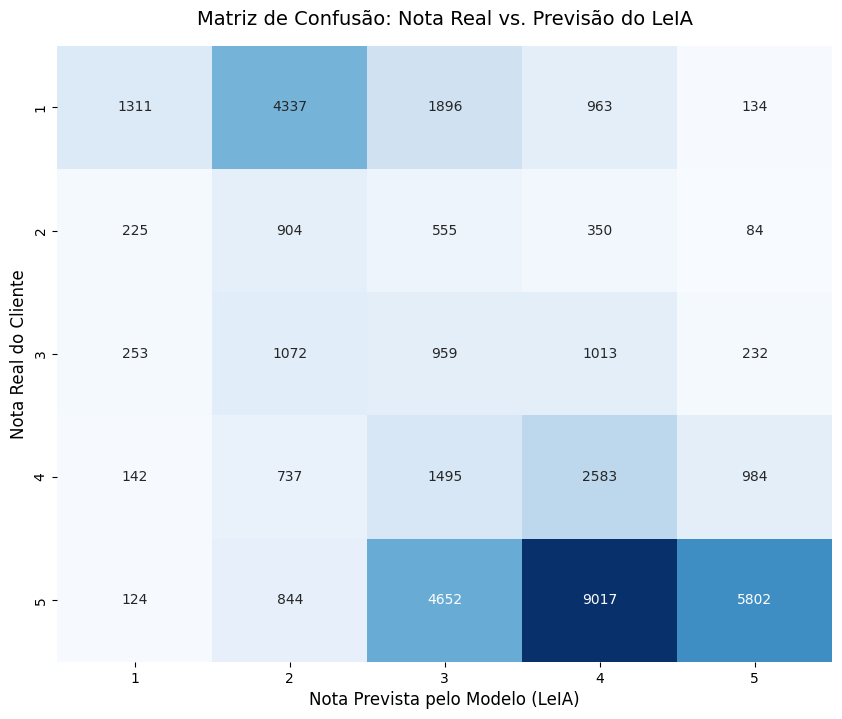

In [ ]:
# 1. Calculando a matriz de confusão
# Usamos o parâmetro labels para forçar a ordem exata das estrelas de 1 a 5 no eixo
cm = confusion_matrix(
    df_s_comentario['nota_avaliacao'],
    df_s_comentario['nota_leIA'],
    labels=[1, 2, 3, 4, 5]
)

# 2. Plotando a matriz
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,        # Liga os números dentro dos quadrados
    fmt='d',           # Formata como número inteiro (sem casas decimais)
    cmap='Blues',      # Escala de cores (quanto mais azul, maior o volume)
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5],
    cbar=False         # Tira a barra de cores lateral para um visual mais limpo
)

plt.title('Matriz de Confusão: Nota Real vs. Previsão do LeIA', fontsize=14, pad=15)
plt.xlabel('Nota Prevista pelo Modelo (LeIA)', fontsize=12)
plt.ylabel('Nota Real do Cliente', fontsize=12)

plt.show()

Observando a matriz de confusão, é possível notar a acentuação de divergências na categoria de nota 1 e 5

---

*Vamos entender o motivo disto acontecer*

/tmp/ipykernel_21103/2544806192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


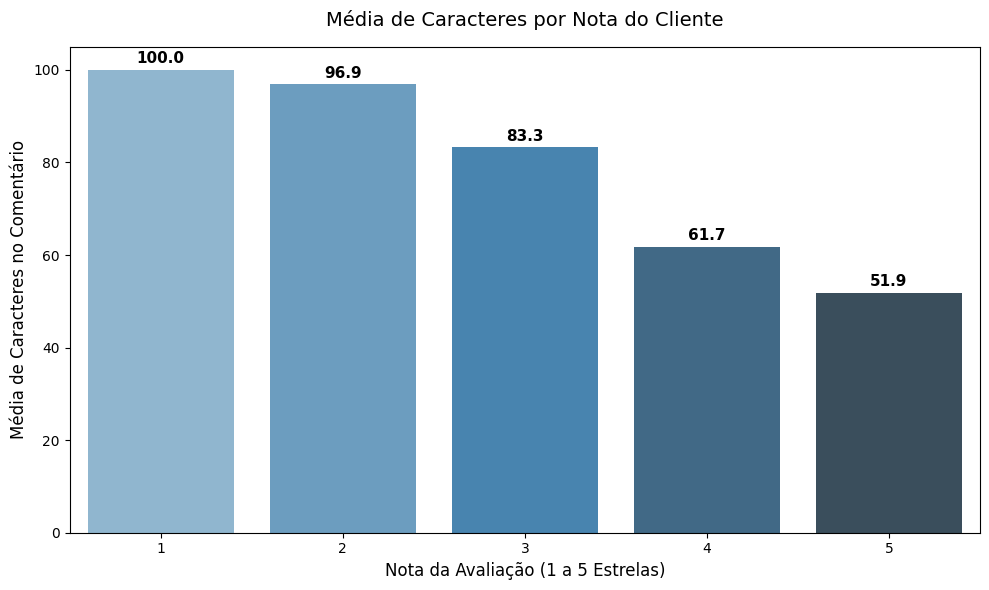

In [ ]:
# 1. Tratando os nulos e calculando a quantidade de caracteres
# Substituímos os <NA> por texto vazio e medimos o comprimento da string
df_s_comentario['tamanho_comentario'] = df_s_comentario['mensagem_comentario'].fillna('').str.len()

# 2. Configurando o gráfico
plt.figure(figsize=(10, 6))

# O barplot do seaborn calcula e mostra automaticamente a MÉDIA por padrão
sns.barplot(
    data=df_s_comentario,
    x='nota_avaliacao',
    y='tamanho_comentario',
    palette='Blues_d',
    errorbar=None # Remove as linhas de erro para manter o gráfico limpo
)

plt.title('Média de Caracteres por Nota do Cliente', fontsize=14, pad=15)
plt.xlabel('Nota da Avaliação (1 a 5 Estrelas)', fontsize=12)
plt.ylabel('Média de Caracteres no Comentário', fontsize=12)

# Adicionando os valores exatos em cima de cada barra
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Comentários com nota 5 - maioria na base - tendem a ter menos escrita fazendo com que a análise do modelo para interpretação acabe concentrando mais comentários perto do neutro. O leIA não lida bem com poucas ou muitas palavras.

---

### Criando Regras de Negócio
Injetando regras de peso personalizadas

#### Aplicando regras de negócio na análise do modelo

A biblioteca leIA funciona com "regras de negócio" e permite que sejam criadas ou personalizadas atribuindo pesos específicos para palavras, como:
- 'demorou' fará com que o peso da análise seja bastante reduzido;
- 'porém' fará com que seja pouco reduzido;
- 'excelente' aumentará o peso.

---

Criamos diferentes regras para comentários em 1, 2 estrelas e comentários em 4, 5 estrelas de forma a deixar o modelo mais sensível

In [ ]:
# Palavras e emojis que indicam ótimos elogios e devem puxar a nota para cima
regras_positivas = [
    'maravilhoso', 'perfeito', 'amei', 'incrivel', 'recomendo', 'excelente',
    'fantastico', 'extraordinario', 'fabuloso', 'sensacional', 'espetacular',
    'fenomenal', 'impressionante', 'surpreendente',
    # Internetês e Abreviações
    'top', 'show', 'vlw', 'mt bom', 'mto bom', 'blz', '10/10', 'muito top',
    # Emojis
    '😍', '❤️', '🥰', '👏', '⭐', '🌟', '🤩', '👍', '💯', '♥️'
]

# Palavras e emojis que indicam problemas e devem puxar a nota para baixo
regras_negativas = [
    'faltou', 'errado', 'decepcionado', 'mas esperava', 'ruim', 'demorou',
    'nao gostei', 'preco salgado',
    # Internetês e Abreviações
    'nd a ver', 'nada a ver', 'ruimzinho', '+/-', 'deixou a desejar',
    # Emojis
    '😒', '😞', '😕', '👎', '🙄', '😑', '😔'
]

# Palavras, gírias e emojis críticos que devem puxar a nota MUITO mais para baixo
regras_s_negativas = [
    'nao recebi', 'nao chegou', 'defeito', 'quebrado', 'procon', 'atraso',
    'pessimo', 'horrivel', 'lixo', 'nunca mais', 'replica', 'nao recomendo',
    'nao constava', 'nojento', 'desagradavel', 'asqueroso', 'falso',
    'super chateada', 'super chateado', 'responder urgente', 'reclamacao',
    'troca do produto', 'amassado', 'riscado',
    # Internetês, Alertas e Palavrões
    'pqp', 'fdp', 'vsf', 'nao comprem', 'n comprem', 'dinheiro jogado fora', '0/10', 'golpe',
    # Emojis extremos
    '😡', '🤬', '🤮', '💩', '🤡', '👎👎', '🚫', '😤'
]

In [ ]:
# Função auxiliar para remover acentos
def remover_acentos(texto):
    # O normalize 'NFKD' separa a letra base do seu acento
    nfkd = unicodedata.normalize('NFKD', texto)
    # Reconstruímos a string ignorando os caracteres que são puramente marcas de acento
    texto_sem_acento = "".join([c for c in nfkd if not unicodedata.combining(c)])
    return texto_sem_acento

In [ ]:
# Função principal
def calcular_sentimento_refinado(linha):
    texto = linha['mensagem_comentario']
    nota = linha['nota_avaliacao']

    if pd.isna(texto):
        return 0.0

    texto_minusc = str(texto).lower()

    # Passo 1: O LeIA avalia o texto COM acentos
    resultado = analyzer.polarity_scores(texto_minusc)
    score_final = resultado['compound']

    # Passo 2: Removemos os acentos para a nossa verificação manual
    texto_busca = remover_acentos(texto_minusc)

    # Passo 3: Aplicando as Regras de Negócios Condicionais
    # Se a nota é 4 ou 5, procuramos contradições negativas para derrubar o score
    if nota in [4, 5]:
        for palavra in regras_negativas:
            if palavra in texto_busca:
                score_final -= 0.3
                break

    # Se a nota é 1 ou 2, procuramos contradições positivas para subir o score
    elif nota in [1, 2]:
        for palavra in regras_positivas:
            if palavra in texto_busca:
                score_final += 0.3
                break
        # Evitando comentários sarcásticos ou educados, penalidade maior
        for palavra in regras_s_negativas:
            if palavra in texto_busca:
                score_final -= 0.4
                break

    # Passo 4: Garantindo os limites matemáticos (-1.0 a 1.0)
    if score_final < -1.0:
        score_final = -1.0
    elif score_final > 1.0:
        score_final = 1.0

    return score_final

In [ ]:
print("Aplicando o LeIA com Regras de Negócio...")

# Coluna 1: O Peso Numérico (-1 a 1)
# O .apply() vai rodar a nossa função linha por linha na coluna de mensagens
df_s_comentario['peso_sentimental_leIA_RN'] = df_s_comentario.apply(calcular_sentimento_refinado, axis=1)

# Coluna 2: A Identificação (Categoria)
# 6 pontos de corte para criar 5 intervalos
#cortes = [-1.01, -0.4, -0.05, 0.05, 0.5, 1.01]
cortes = [-1.01, -0.6, -0.1, 0.1, 0.6, 1.01]

# As categorias agora são os valores das estrelas (como números ou strings)
categorias = [1, 2, 3, 4, 5]

df_s_comentario['nota_leIA_RN'] = pd.cut(
    df_s_comentario['peso_sentimental_leIA_RN'],
    bins=cortes,
    labels=categorias,
    include_lowest=True
)
df_s_comentario['nota_leIA_RN'] = df_s_comentario['nota_leIA_RN'].astype(float)

Aplicando o LeIA com Regras de Negócio...


#### Avaliando nota atribuída pelo leIA com Regras de Negócio

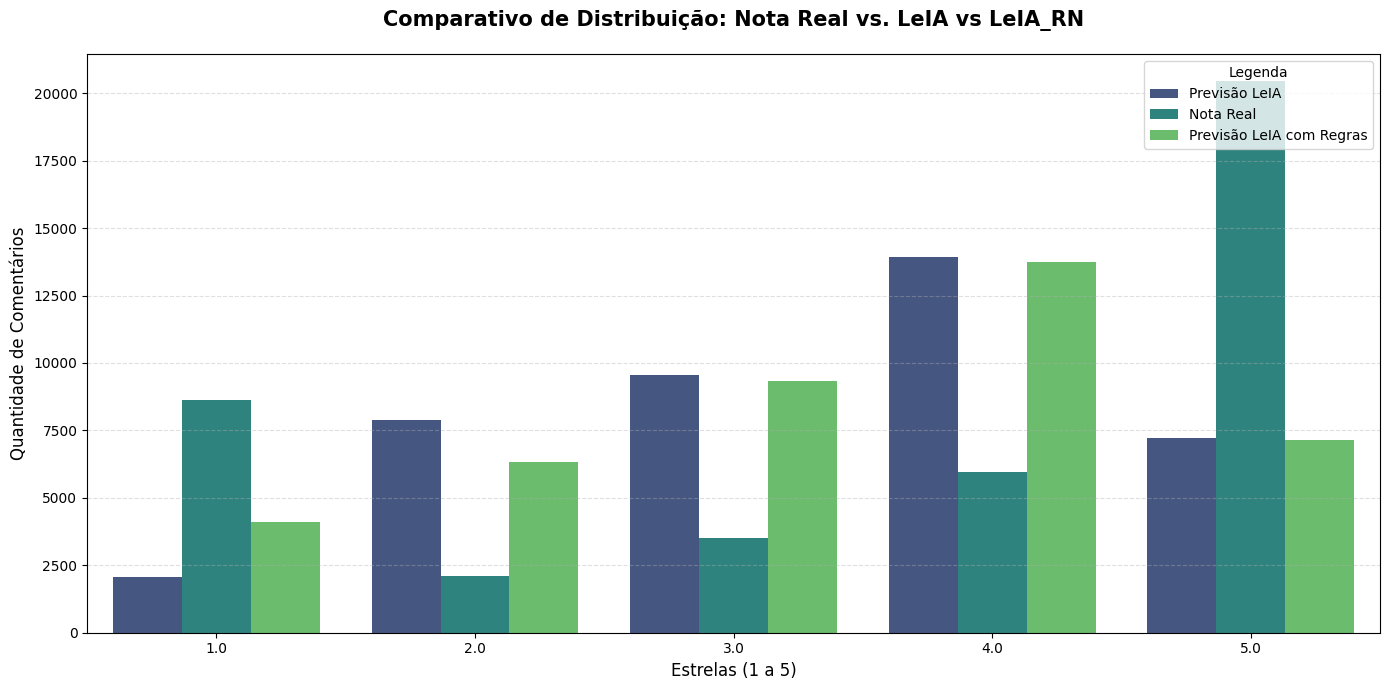

In [ ]:
# 1. Preparando os dados unificados (Derretendo as 3 colunas)
df_plot_trio = df_s_comentario[['nota_leIA', 'nota_avaliacao', 'nota_leIA_RN']].melt(
    var_name='Tipo de Nota',
    value_name='Estrelas'
)

# 2. Mapeando os nomes para a legenda ficar perfeita
df_plot_trio['Tipo de Nota'] = df_plot_trio['Tipo de Nota'].map({
    'nota_leIA': 'Previsão LeIA',
    'nota_avaliacao': 'Nota Real',
    'nota_leIA_RN': 'Previsão LeIA com Regras',
})

# 3. Criando o gráfico
plt.figure(figsize=(14, 7))
sns.countplot(
    data=df_plot_trio,
    x='Estrelas',
    hue='Tipo de Nota'
    ,palette='viridis'
)

# 4. Ajustes estéticos e títulos
plt.title('Comparativo de Distribuição: Nota Real vs. LeIA vs LeIA_RN', fontsize=15, pad=20, weight='bold')
plt.xlabel('Estrelas (1 a 5)', fontsize=12)
plt.ylabel('Quantidade de Comentários', fontsize=12)

# Deixando a legenda organizada e grid leve ao fundo
plt.legend(title='Legenda', loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

É possível observar significativa melhora em notas baixas mas quase nenhum efeito em notas acima de 3 - conforme visto sobre a dificuldade do leIA com poucas palavras -

---

*Vamos observar alguns outliers da regra de negócio para entender a conclusão do modelo novamente*

In [ ]:
# Definindo uma semente
semente = 42

# 1. Isolando 3 outliers da Nota 1 (Score muito positivo)
outliers_nota1 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 1) &
    (df_s_comentario['peso_sentimental_leIA_RN'] > 0.75)
].sample(n=3, random_state=semente)

# 2. Isolando 3 outliers da Nota 2 (Score muito positivo)
outliers_nota2 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 2) &
    (df_s_comentario['peso_sentimental_leIA_RN'] > 0.65)
].sample(n=3, random_state=semente)

# 3. Isolando 3 outliers da Nota 4 (Score muito negativo)
outliers_nota4 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 4) &
    (df_s_comentario['peso_sentimental_leIA_RN'] < -0.75)
].sample(n=3, random_state=semente)

# 4. Isolando 3 outliers da Nota 5 (Score muito negativo)
outliers_nota5 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 5) &
    (df_s_comentario['peso_sentimental_leIA_RN'] < -0.60)
].sample(n=3, random_state=semente)

# Unindo os recortes em uma única tabela para leitura
amostra_outliers = pd.concat([outliers_nota1, outliers_nota2, outliers_nota4, outliers_nota5])

# Configurando o Pandas para não cortar os textos longos na tela
pd.set_option('display.max_colwidth', None)

# Exibindo o resultado da amostragem
display(amostra_outliers[['nota_avaliacao', 'nota_leIA_RN', 'peso_sentimental_leIA_RN','mensagem_comentario']])

# Resetando a configuração de visualização para o padrão depois da leitura
pd.reset_option('display.max_colwidth')

,nota_avaliacao,nota_leIA_RN,peso_sentimental_leIA_RN,mensagem_comentario
98270,1,5.0,0.7906,"A carteira é linda, porém é muito grande e for a do padrão das carteiras tradicionais."
52426,1,5.0,0.7964,"Bem pouquíssimo produto, e deixa a pele muito oleosa brilha muito por ser um preço salgado esperava mais do produto, ainda bem que comprei pra testar ."
77023,1,5.0,1.0000,Entrega super rápida... Produto com ótima qualidade... Super recomendo...
78747,2,5.0,0.6808,"O anuncio não foi claro , a imagem não condiz ... muito pequeno o pendente achei que era bem maior , não temproteção para a lampada ela fica exposta ... enfim tem que melhorar o anunciado"
92028,2,5.0,0.7269,"Equipe lannister recebi o produto incompleto, ou seja, está faltando uma mochila Barbie Grande. lannister tive que retirar a mercadoria incompleta na lojas do correios. Atenciosamente."
282,2,5.0,0.6908,"tenho outro sling de outra marca com tecido muito mais macio, maleável e agradável"
3531,4,1.0,-0.7644,Só não vou pedir pra trocar porque eu vo ter o trabalho de ir no correio! O produto veio com uma estampa de caveira mexicana que não constava na foto eu queria sem essa estampa mais infelizmente .
73788,4,1.0,-0.8113,"Demorou um pouco a entrega, mas a culpa foi dos correios."
23188,4,1.0,-0.8462,"Ótimo produto, mas foi muito mal embalado, sem proteção entre a fita adesiva e o capacete, até agora não consegui tirar toda a cola grudada nele."
44072,5,1.0,-0.7650,"não recebi o produto no prazo, porem endento que o problema não foi da loja, pois quando eu comprei em seguida tivemos a greve dos caminhoneiros."


É possível observar que o modelo já não confunde palavras de expressão intensa mas continua com dificuldades em comentários com mais de uma afirmação ou com ponderações que deveriam ser jogadas ao neutro

---

*Comparando o modelo diretamente com a nota dada pelo cliente*

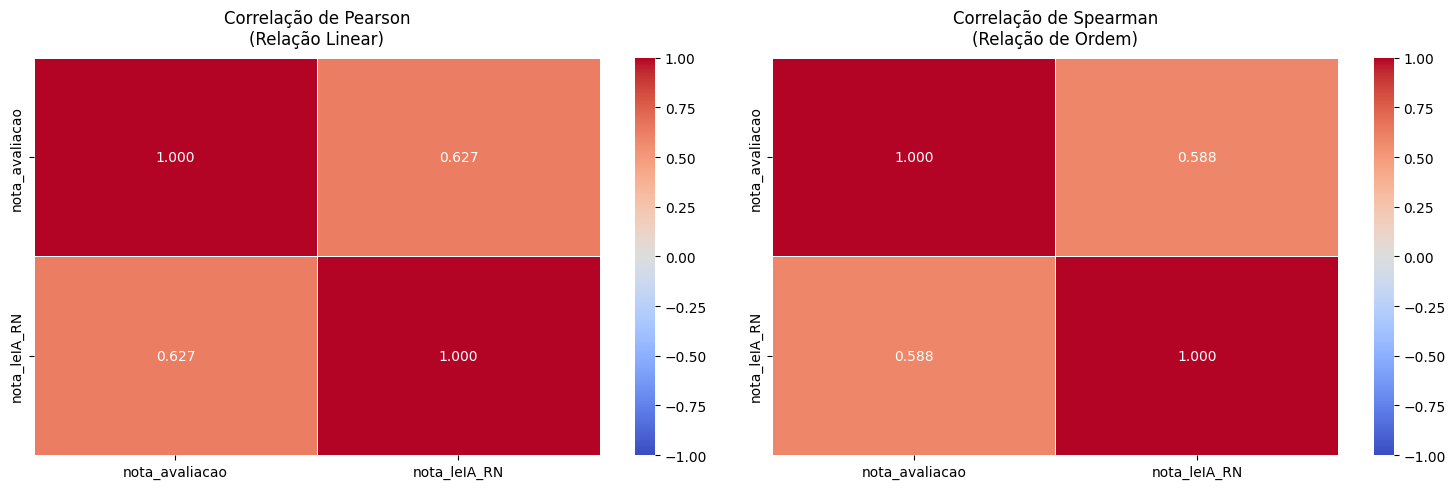

In [ ]:
# Criando um mini-dataframe só com as duas variáveis
df_correlacao = df_s_comentario[['nota_avaliacao', 'nota_leIA_RN']]

# 1. Calculando as duas matrizes de correlação
corr_pearson = df_correlacao.corr(method='pearson')
corr_spearman = df_correlacao.corr(method='spearman')

# 2. Criando a figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfico 1: Pearson (Esquerda) ---
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=axes[0] # Define que este mapa vai para o primeiro quadrado
)
axes[0].set_title('Correlação de Pearson\n(Relação Linear)', fontsize=12, pad=10)

# --- Gráfico 2: Spearman (Direita) ---
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=axes[1] # Define que este mapa vai para o segundo quadrado
)
axes[1].set_title('Correlação de Spearman\n(Relação de Ordem)', fontsize=12, pad=10)

# 3. Ajustando o espaçamento para não sobrepor os textos
plt.tight_layout()
plt.show()

A interpretação do resultado aplicando regras de negócio demonstrou que o modelo melhorou sua correlação com a nota real

---

*Vamos comparar a quantia de divergências com matriz de confusão*

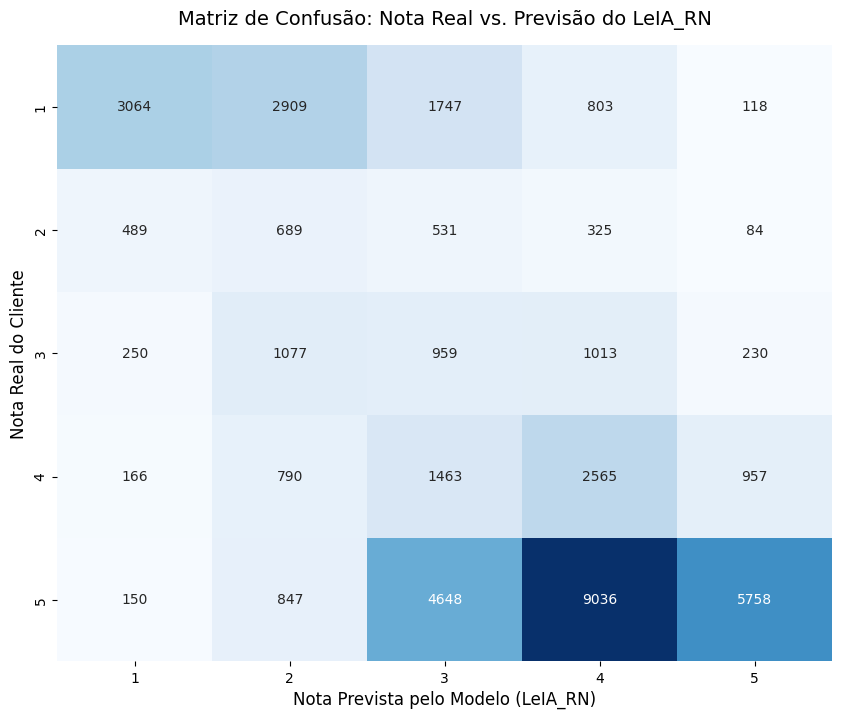

In [ ]:
# 1. Calculando a matriz de confusão
# Usamos o parâmetro labels para forçar a ordem exata das estrelas de 1 a 5 no eixo
cm = confusion_matrix(
    df_s_comentario['nota_avaliacao'],
    df_s_comentario['nota_leIA_RN'],
    labels=[1, 2, 3, 4, 5]
)

# 2. Plotando a matriz
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,        # Liga os números dentro dos quadrados
    fmt='d',           # Formata como número inteiro (sem casas decimais)
    cmap='Blues',      # Escala de cores (quanto mais azul, maior o volume)
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5],
    cbar=False         # Tira a barra de cores lateral para um visual mais limpo
)

plt.title('Matriz de Confusão: Nota Real vs. Previsão do LeIA_RN', fontsize=14, pad=15)
plt.xlabel('Nota Prevista pelo Modelo (LeIA_RN)', fontsize=12)
plt.ylabel('Nota Real do Cliente', fontsize=12)

plt.show()

Observando a matriz de confusão, é possível notar a acentuação de divergências na categoria de nota 5 demonstrando que mesmo com regras de negócio personalizadas, o leIA sofre limitição diante de poucos caracteres.

---


## Transformer
Modelo de análise sentimental com aprendizado de máquina e contexto de frase

### Análise Sentimental: PySentimiento
Treinado com base em comentários de rede social. O **pysentimiento** usa um modelo BERT fine-tuned em dados brasileiros.
Diferentemente do LeIA (léxico), ele entende contexto completo da frase,
dispensando normalização de acentos e regras de negócio manuais.

#### Criando a análise sentimental do comentário

In [ ]:
!pip install pysentimiento --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 23.9 MB/s eta 0:00:00


In [ ]:
from pysentimiento import create_analyzer

analyzer_pysent = create_analyzer(task='sentiment', lang='pt')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/952 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/562 [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/799k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

##### Criando a nova coluna de peso sentimental
Isto são "traduções numéricas" para os comentários de -1 a 1

In [ ]:
def calcular_pysent(texto):
    if pd.isna(texto) or str(texto).strip() == '':
        return 0.0  # Retorna o neutro absoluto se não houver texto suficiente
    try:
        resultado = analyzer_pysent.predict(str(texto))
        # Multiplicamos ou mantemos o arredondamento de -1.0 a 1.0
        score = round(float(resultado.probas['POS']) - float(resultado.probas['NEG']), 4)
        return score
    except Exception:
        return 0.0

In [ ]:
from tqdm import tqdm
tqdm.pandas(desc='pysentimiento')

In [ ]:
print('Aplicando pysentimiento ao df_s_comentario...')

# Coluna 1: O Peso Numérico (-1 a 1) preenchido pela função ajustada
df_s_comentario['peso_sentimental_pysenti'] = df_s_comentario['mensagem_comentario'].progress_apply(calcular_pysent)

# Coluna 2: A Identificação da Categoria por Estrelas
# 6 pontos de corte para criar os 5 intervalos equivalentes ao LeIA
cortes = [-1.01, -0.6, -0.1, 0.1, 0.6, 1.01]
categorias = [1, 2, 3, 4, 5]

df_s_comentario['nota_pysenti'] = pd.cut(
    df_s_comentario['peso_sentimental_pysenti'],
    bins=cortes,
    labels=categorias,
    include_lowest=True
)
df_s_comentario['nota_pysenti'] = df_s_comentario['nota_pysenti'].astype(float)

Aplicando pysentimiento ao df_s_comentario...


pysentimiento: 100%|██████████| 40668/40668 [08:30<00:00, 79.67it/s]


In [ ]:
display(df_s_comentario[['nota_avaliacao', 'peso_sentimental_leIA_RN', 'nota_leIA_RN', 'peso_sentimental_pysenti', 'nota_pysenti', 'mensagem_comentario']].head())

,nota_avaliacao,peso_sentimental_leIA_RN,nota_leIA_RN,peso_sentimental_pysenti,nota_pysenti,mensagem_comentario
0,4,0.5023,4.0,-0.9508,1.0,"Não testei o produto ainda, mas ele veio corre..."
1,4,0.4215,4.0,0.9914,5.0,Muito bom o produto.
3,5,0.5719,4.0,0.3760,4.0,O produto foi exatamente o que eu esperava e e...
6,2,-0.4939,2.0,-0.9633,1.0,fiquei triste por n ter me atendido.
10,1,0.0000,3.0,0.0229,3.0,Aguardando retorno da loja


Visualmente, já percebemos uma melhoria na precisão do novo modelo que não tem tantas dificuldades com poucas palavras ou ponderações

#### Avaliando nota atribuída pelo pysentimiento

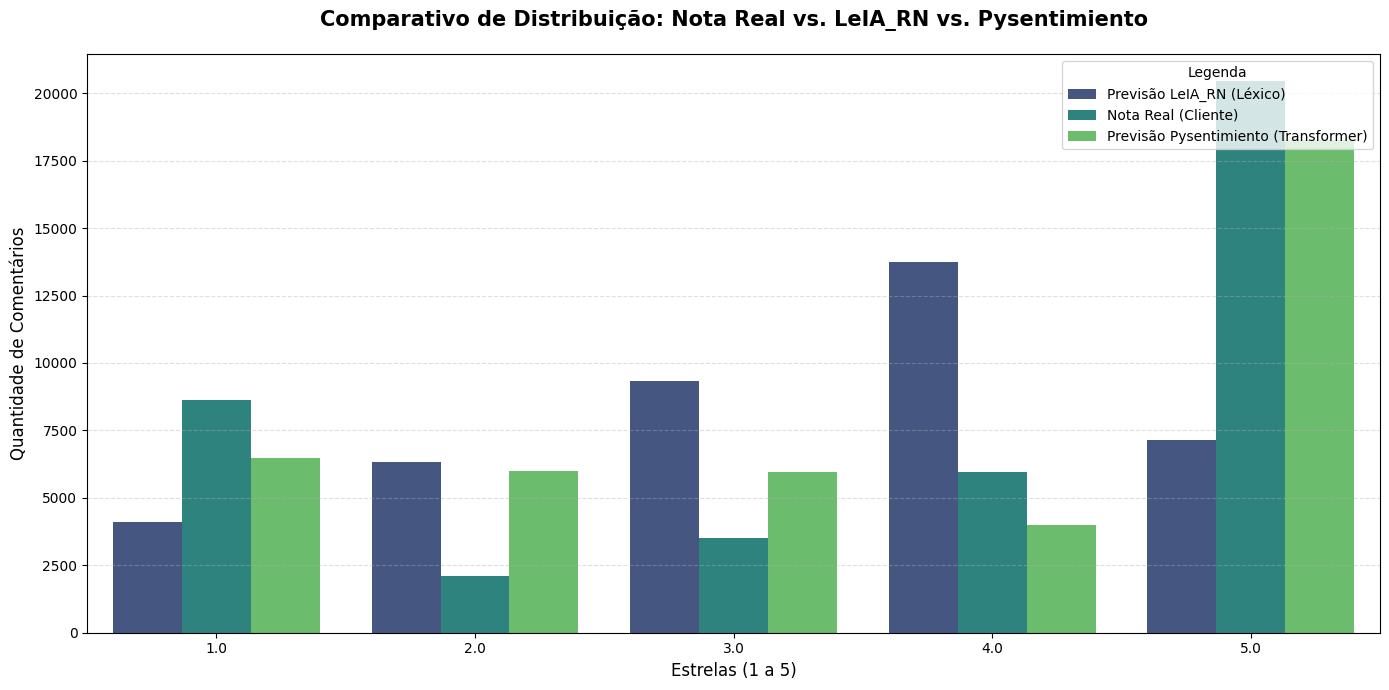

In [ ]:
# 1. Preparando os dados unificados
df_plot_trio = df_s_comentario[['nota_leIA_RN', 'nota_avaliacao', 'nota_pysenti']].melt(
    var_name='Tipo de Nota',
    value_name='Estrelas'
)

# 2. Mapeando os nomes para a legenda ficar perfeita
df_plot_trio['Tipo de Nota'] = df_plot_trio['Tipo de Nota'].map({
    'nota_leIA_RN': 'Previsão LeIA_RN (Léxico)',
    'nota_avaliacao': 'Nota Real (Cliente)',
    'nota_pysenti': 'Previsão Pysentimiento (Transformer)'
})

# 3. Criando o gráfico com o trio de barras
plt.figure(figsize=(14, 7))
sns.countplot(
    data=df_plot_trio,
    x='Estrelas',
    hue='Tipo de Nota'
    ,palette='viridis'
)

# 4. Ajustes estéticos e títulos
plt.title('Comparativo de Distribuição: Nota Real vs. LeIA_RN vs. Pysentimiento', fontsize=15, pad=20, weight='bold')
plt.xlabel('Estrelas (1 a 5)', fontsize=12)
plt.ylabel('Quantidade de Comentários', fontsize=12)

# Deixando a legenda organizada e grid leve ao fundo
plt.legend(title='Legenda', loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Comparando lado a lado, pela precisão do pysentimiento, ele tende a seguir ainda mais as notas originais do que o leIA

---

*Vamos observar algumas notas extremas do modelo curva para avaliar sua interpretação*

In [ ]:
semente = 42

# 1. Nota 1 com score positivo → modelo achou que era nota 5 (score > 0.6), cliente odiou
outliers_nota1 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 1) &
    (df_s_comentario['peso_sentimental_pysenti'] > 0.60)
].sample(n=5, random_state=semente, replace=True)

# 2. Nota 2 com score muito positivo → modelo achou bem positivo, cliente não gostou
outliers_nota2 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 2) &
    (df_s_comentario['peso_sentimental_pysenti'] > 0.60)
].sample(n=3, random_state=semente, replace=True)

# 3. Nota 4 com score muito negativo → modelo achou bem negativo, cliente gostou
outliers_nota4 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 4) &
    (df_s_comentario['peso_sentimental_pysenti'] < -0.60)
].sample(n=3, random_state=semente, replace=True)

# 4. Nota 5 com score negativo → modelo achou que era nota 1 (score < -0.6), cliente amou
outliers_nota5 = df_s_comentario[
    (df_s_comentario['nota_avaliacao'] == 5) &
    (df_s_comentario['peso_sentimental_pysenti'] < -0.60)
].sample(n=3, random_state=semente, replace=True)

amostra_outliers = pd.concat([outliers_nota1, outliers_nota2, outliers_nota4, outliers_nota5])
pd.set_option('display.max_colwidth', None)

# Exibindo as colunas exatas do pysentimiento que guardamos na célula anterior
display(amostra_outliers[['nota_avaliacao', 'nota_pysenti', 'peso_sentimental_pysenti', 'mensagem_comentario']])

pd.reset_option('display.max_colwidth')

,nota_avaliacao,nota_pysenti,peso_sentimental_pysenti,mensagem_comentario
69190,1,5.0,0.8146,"Entrega rápida, mas esperava uma qualidade melhor do tapete, pelo preço aq na cidade encontrei melhor,mas gostei do desenho."
18608,1,5.0,0.7474,fico aguardando
87867,1,5.0,0.9896,Excelente
74214,1,5.0,0.8825,é muito fino
31987,1,5.0,0.7950,"RECEBI UM PRODUTO F-A-L-S-I-F-I-C-A-D-O. Ñ SABE NEM DISFARÇAR. TOTALMENTE DIFERENTE DO ORIGINAL. DEMORA PARA RESOLVER MEU PROBLEMA, NÃO CONSIGO TROCAR NEM PEDIR REEMBOLSO. NAO COMPREM COM targaryen NUNCA!"
51218,2,5.0,0.6040,Gostei do jogo de toalhas de banho que encomendei só que veio dois jogos dá mesma cor e eu tinha pedido um jogo de cor vinho e outro azul.
9057,2,5.0,0.7969,"Já tive um Skullcandy do mesmo modelo, a qualidade era inigualável, detalhes de acabamento perfeitos, experiência sonora agradável e potente, principalmente no destaque dos graves....este não é Skull."
73732,2,5.0,0.9891,produto bom minha filha amou
19590,4,1.0,-0.7825,O que seria mais fácil seria fazer uma nota só para os produtos qdo vc fecha um pedido sem ter terminar as compras e ruim .Deveria qdo vc coloca a compra no carrinho haver tendo retorno mais facilita
91571,4,1.0,-0.7855,Minha opinião é que a empresa deveria informar todos os rastreamentos . uma vez que fiz 1 pedido com 03 unidades . sendo que recebi só o primeiro rastreamento que continha 01 unidade. entrei em pânico


É possível observar que o modelo lida MUITO melhor com comentários intensos ou com mais de uma afirmação. Ele não consegue lidar bem com formas de comunicação web como recorte de palavras com hífen ou jeitinho brasileiro de se expressar

---

*Comparando o modelo diretamente com a nota dada pelo cliente*

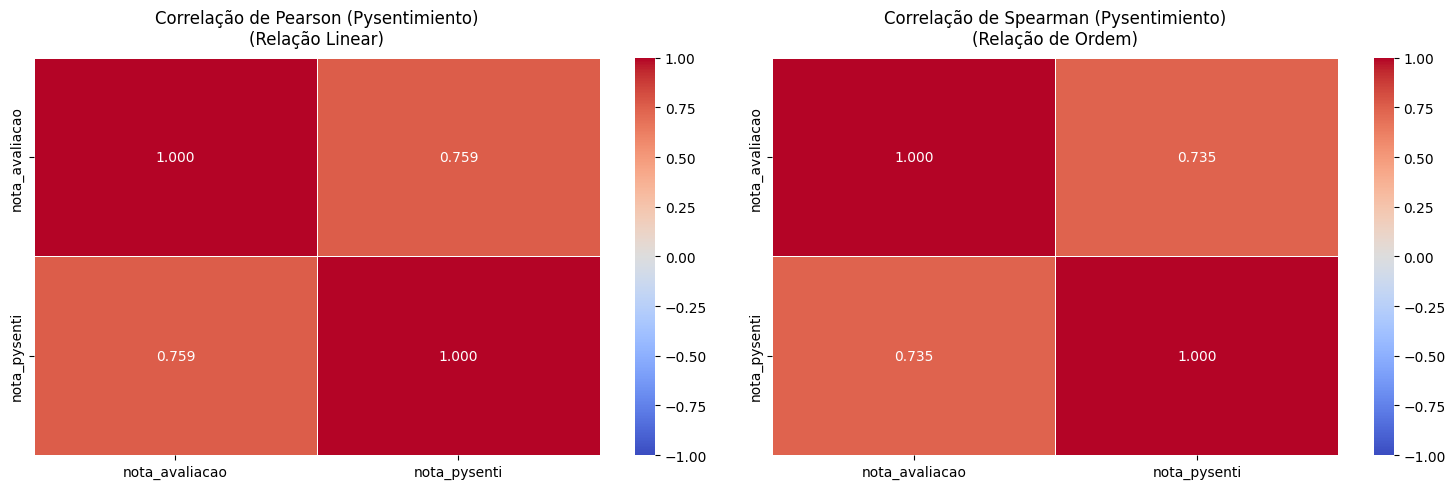

In [ ]:
# 1. Criando um mini-dataframe só com as duas variáveis (agora usando o pysentimiento)
df_correlacao_pysenti = df_s_comentario[['nota_avaliacao', 'nota_pysenti']]

# 2. Calculando as duas matrizes de correlação
corr_pearson_pysenti = df_correlacao_pysenti.corr(method='pearson')
corr_spearman_pysenti = df_correlacao_pysenti.corr(method='spearman')

# 3. Criando a figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfico 1: Pearson (Esquerda) ---
sns.heatmap(
    corr_pearson_pysenti,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=axes[0] # Define que este mapa vai para o primeiro quadrado
)
axes[0].set_title('Correlação de Pearson (Pysentimiento)\n(Relação Linear)', fontsize=12, pad=10)

# --- Gráfico 2: Spearman (Direita) ---
sns.heatmap(
    corr_spearman_pysenti,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=axes[1] # Define que este mapa vai para o segundo quadrado
)
axes[1].set_title('Correlação de Spearman (Pysentimiento)\n(Relação de Ordem)', fontsize=12, pad=10)

# 4. Ajustando o espaçamento para não sobrepor os textos
plt.tight_layout()
plt.show()

É apresentado uma correlação acima de 0.7 seja em comparações de valores reais ou comparando o posicionamento das notas. Há uma análise otimizada do modelo

# Comparação de modelos finais

In [ ]:
colunas_de_nota = ['nota_avaliacao', 'nota_vader', 'nota_leIA', 'nota_leIA_RN', 'nota_pysenti']
for col in colunas_de_nota:
    df_s_comentario[col] = df_s_comentario[col].astype(int)

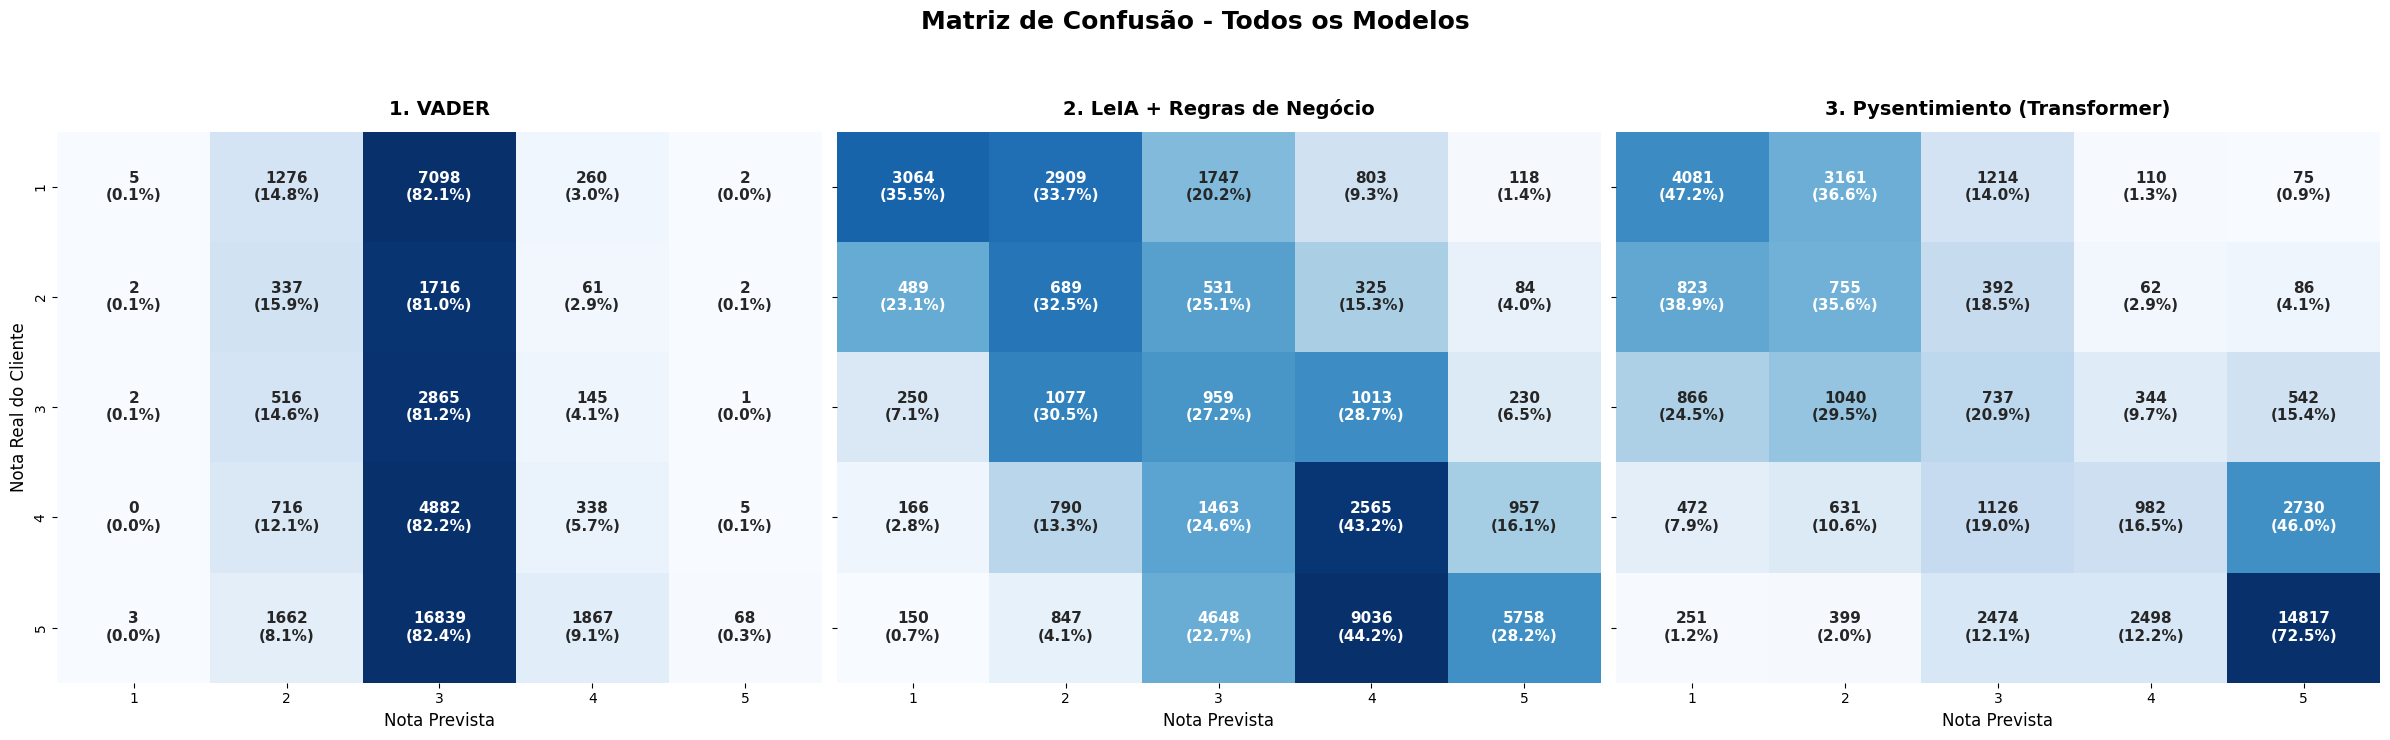

In [ ]:
# 1. Definições básicas
labels = [1, 2, 3, 4, 5]

# 2. Calculando as matrizes brutas para os 3 cenários
cm_vader      = confusion_matrix(df_s_comentario['nota_avaliacao'], df_s_comentario['nota_vader'], labels=labels)
cm_leia_rn   = confusion_matrix(df_s_comentario['nota_avaliacao'], df_s_comentario['nota_leIA_RN'], labels=labels)
cm_pysenti   = confusion_matrix(df_s_comentario['nota_avaliacao'], df_s_comentario['nota_pysenti'], labels=labels)

# 3. Função mágica para criar o texto duplo (Quantidade + %) por célula
def gerar_ao_quadrado_labels(cm):
    # Normaliza por linha (soma horizontal = 100%)
    cm_porcentagem = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Cria uma matriz de strings vazia no mesmo formato
    labels_customizados = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            qtd = cm[i, j]
            pct = cm_porcentagem[i, j] * 100
            # Monta a string com quebra de linha \n
            labels_customizados[i, j] = f"{qtd}\n({pct:.1f}%)"

    return cm_porcentagem, labels_customizados

# Aplicando a função para as 3 matrizes
comp_vader, text_vader     = gerar_ao_quadrado_labels(cm_vader)
comp_leia_rn, text_leia_rn = gerar_ao_quadrado_labels(cm_leia_rn)
comp_pysenti, text_pysenti = gerar_ao_quadrado_labels(cm_pysenti)

# 4. Configurando a figura com 1 linha e 3 colunas
# sharey=True compartilha o eixo Y (Nota Real) para ficar limpo
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# --- MATRIZ 1: VADER ---
sns.heatmap(
    comp_vader, annot=text_vader, fmt='', cmap='Blues',
    xticklabels=labels, yticklabels=labels, cbar=False, ax=axes[0],
    annot_kws={"size": 11, "weight": "bold"} # Estilo do texto interno
)
axes[0].set_title('1. VADER', fontsize=14, pad=12, weight='bold')
axes[0].set_xlabel('Nota Prevista', fontsize=12)
axes[0].set_ylabel('Nota Real do Cliente', fontsize=12)

# --- MATRIZ 2: LeIA com Regras de Negócio ---
sns.heatmap(
    comp_leia_rn, annot=text_leia_rn, fmt='', cmap='Blues',
    xticklabels=labels, yticklabels=labels, cbar=False, ax=axes[1],
    annot_kws={"size": 11, "weight": "bold"}
)
axes[1].set_title('2. LeIA + Regras de Negócio', fontsize=14, pad=12, weight='bold')
axes[1].set_xlabel('Nota Prevista', fontsize=12)

# --- MATRIZ 3: Pysentimiento (Transformer) ---
sns.heatmap(
    comp_pysenti, annot=text_pysenti, fmt='', cmap='Blues',
    xticklabels=labels, yticklabels=labels, cbar=False, ax=axes[2],
    annot_kws={"size": 11, "weight": "bold"}
)
axes[2].set_title('3. Pysentimiento (Transformer)', fontsize=14, pad=12, weight='bold')
axes[2].set_xlabel('Nota Prevista', fontsize=12)

# Título mestre do slide
plt.suptitle('Matriz de Confusão - Todos os Modelos', fontsize=18, weight='bold', y=1.05)

plt.tight_layout()
plt.show()

Comparando os modelos lado a lado, é perceptível a evolução na precisão de acertos com o pysentimiento acertando 72% de notas 5 (maioria das avaliações na base de dados). Embora o modo como os modelos operam seja diferente, todos apresentam maiores gargalos em notas baixas - acertos não passam de 50% -. Isto pode ser por conta da soma de frases longas com diversas pontuações (mas, entretanto, porém), poucos registros de notas baixas na base de dados como um todo ou ironia/sarcasmo nos comentários.

---


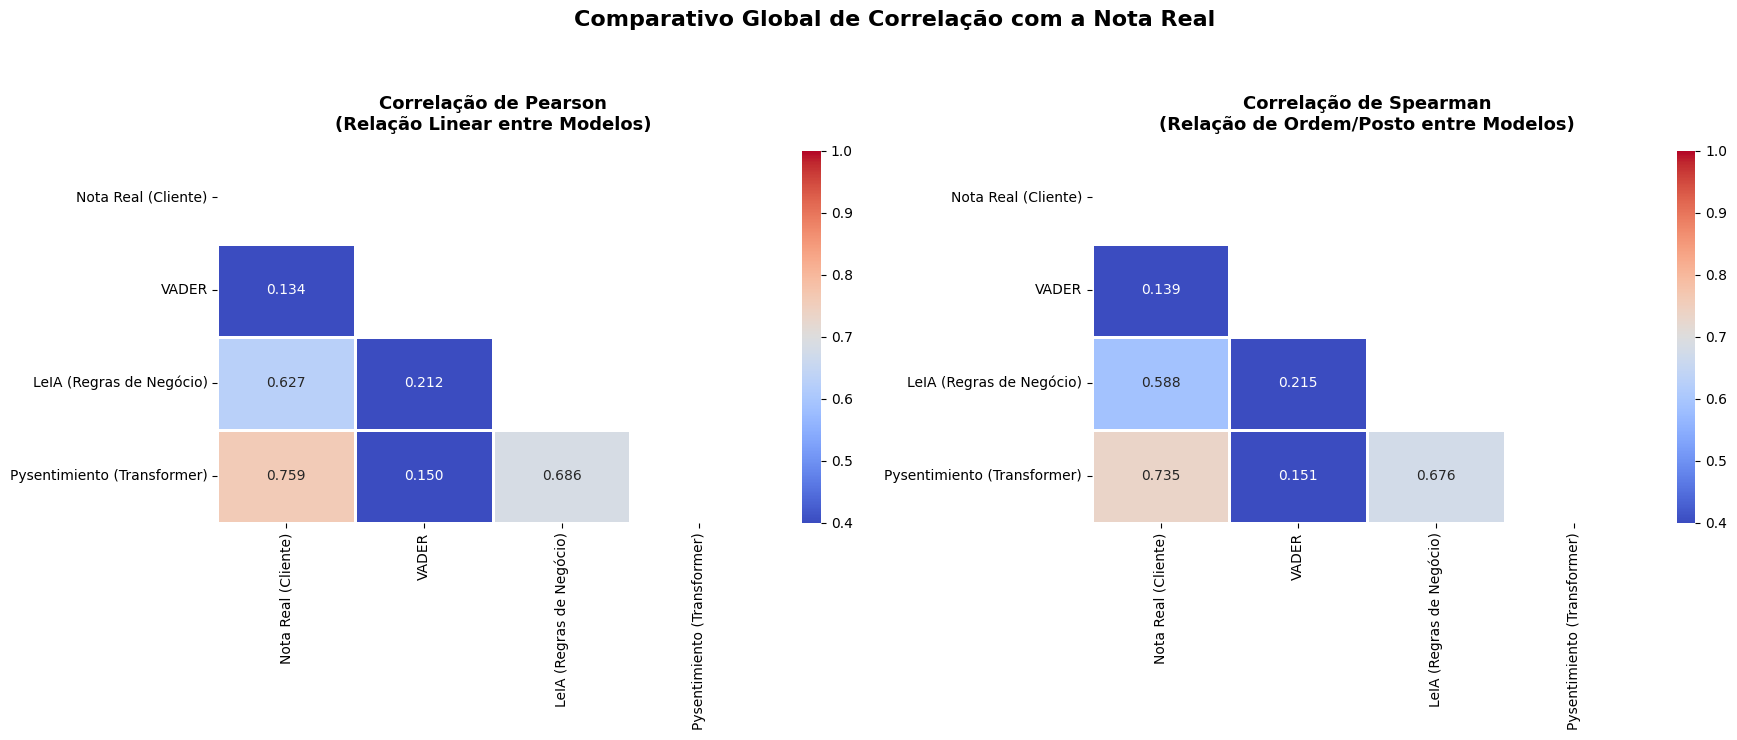

In [ ]:
# 1. Criando o mini-dataframe com os nomes profissionais para exibição
df_correlacao_total = df_s_comentario[[
    'nota_avaliacao',
    'nota_vader',
    'nota_leIA_RN',
    'nota_pysenti'
]].rename(columns={
    'nota_avaliacao': 'Nota Real (Cliente)',
    'nota_vader': 'VADER',
    'nota_leIA_RN': 'LeIA (Regras de Negócio)',
    'nota_pysenti': 'Pysentimiento (Transformer)'
})

# 2. Calculando as matrizes de correlação
corr_pearson_total = df_correlacao_total.corr(method='pearson')
corr_spearman_total = df_correlacao_total.corr(method='spearman')

# 3. Criando a MÁSCARA para esconder a diagonal e a parte superior
# np.triu(np.ones_like(..., dtype=bool)) gera True para a diagonal e acima dela
mask = np.triu(np.ones_like(corr_pearson_total, dtype=bool))

# 4. Criando a figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: Pearson (Esquerda) ---
sns.heatmap(
    corr_pearson_total,
    mask=mask,          # <--- A mágica acontece aqui!
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=0.4, vmax=1,   # Mantendo o contraste nos ganhos
    linewidths=0.8,
    cbar=True,
    ax=axes[0]
)
axes[0].set_title('Correlação de Pearson\n(Relação Linear entre Modelos)', fontsize=13, pad=15, weight='bold')

# --- Gráfico 2: Spearman (Direita) ---
sns.heatmap(
    corr_spearman_total,
    mask=mask,          # <--- Aplicando a mesma máscara na direita
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=0.4, vmax=1,
    linewidths=0.8,
    cbar=True,
    ax=axes[1]
)
axes[1].set_title('Correlação de Spearman\n(Relação de Ordem/Posto entre Modelos)', fontsize=13, pad=15, weight='bold')

# Título mestre do slide
plt.suptitle('Comparativo Global de Correlação com a Nota Real', fontsize=16, weight='bold', y=1.05)

plt.tight_layout()
plt.show()

Entre os três modelos testados, Pysentimiento apresenta a maior correlação positiva com a nota original dada pelo cliente chegando a ~0.80 de correlação positiva forte.

---


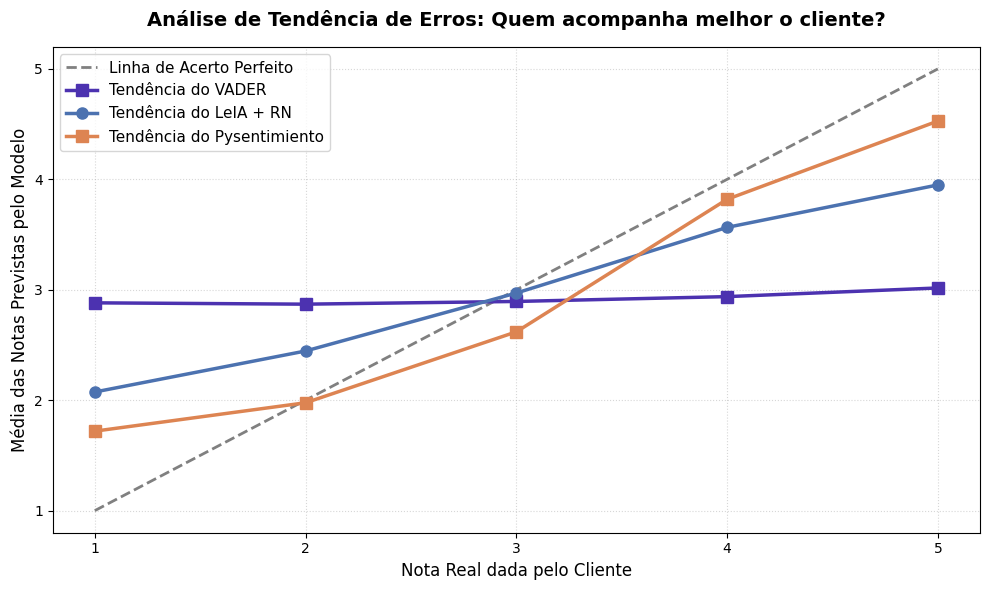

In [ ]:
# 1. 2. Calculando a média das notas previstas para cada nota real do cliente
df_linhas = df_s_comentario.groupby('nota_avaliacao')[['nota_vader', 'nota_leIA_RN', 'nota_pysenti']].mean().reset_index()

# 3. Configurando o gráfico de linhas de tendência
plt.figure(figsize=(10, 6))

# Linha de Referência Ideal (Onde a previsão seria identica à nota real)
plt.plot([1, 5], [1, 5], color='grey', linestyle='--', linewidth=2, label='Linha de Acerto Perfeito')

# Linha do VADER
plt.plot(
    df_linhas['nota_avaliacao'], df_linhas['nota_vader'],
    marker='s', markersize=8, color='#4C32B0', linewidth=2.5, label='Tendência do VADER'
)

# Linha do LeIA com Regras de Negócio
plt.plot(
    df_linhas['nota_avaliacao'], df_linhas['nota_leIA_RN'],
    marker='o', markersize=8, color='#4C72B0', linewidth=2.5, label='Tendência do LeIA + RN'
)

# Linha do Pysentimiento
plt.plot(
    df_linhas['nota_avaliacao'], df_linhas['nota_pysenti'],
    marker='s', markersize=8, color='#DD8452', linewidth=2.5, label='Tendência do Pysentimiento'
)

# 4. Ajustes estéticos
plt.title('Análise de Tendência de Erros: Quem acompanha melhor o cliente?', fontsize=14, pad=15, weight='bold')
plt.xlabel('Nota Real dada pelo Cliente', fontsize=12)
plt.ylabel('Média das Notas Previstas pelo Modelo', fontsize=12)

plt.xticks([1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4, 5])
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)

plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

Visualmente, é possível notar como cada modelo se comporta diante da nota original e como o Pysentimiento tende a ter um acompanhamento fortemente correlacional.

---


#### Estatistíca

In [ ]:
def calcular_gini(y_true, y_pred):
    """
    Calcula o Coeficiente de Gini Normalizado para avaliar a capacidade
    de ordenação e alinhamento do modelo face às notas reais.
    """
    actual = np.asarray(y_true)
    pred = np.asarray(y_pred)
    assert len(actual) == len(pred)

    # Ordena os dados reais com base nas previsões do modelo
    all_data = np.asarray(np.c_[actual, pred, np.arange(len(actual))], dtype=float)
    all_data = all_data[np.lexsort((all_data[:, 2], all_data[:, 1]))]

    total_losses = all_data[:, 0].sum()
    if total_losses == 0:
        return 0.0

    gini_sum = all_data[:, 0].cumsum().sum() / total_losses
    gini_sum -= (len(actual) + 1) / 2.0
    gini_model = gini_sum / len(actual)

    # Calcula o Gini Perfeito (Cenário ideal de acerto de ordenação)
    all_data_perfect = np.asarray(np.c_[actual, actual, np.arange(len(actual))], dtype=float)
    all_data_perfect = all_data_perfect[np.lexsort((all_data_perfect[:, 2], all_data_perfect[:, 1]))]
    gini_sum_perfect = all_data_perfect[:, 0].cumsum().sum() / total_losses
    gini_sum_perfect -= (len(actual) + 1) / 2.0
    gini_perfect = gini_sum_perfect / len(actual)

    # Retorna o Gini Normalizado (varia entre 0.0 e 1.0 para modelos preditivos úteis)
    return gini_model / gini_perfect if gini_perfect != 0 else 0.0

* **MAE (Erro Médio Absoluto):** *Margem de erro física.* Indica, em média, por quantas estrelas o modelo erra a nota real do cliente. Quanto menor, melhor.
* **MSE (Erro Quadrático Médio):** *Termómetro de erros absurdos.* Penaliza severamente os erros grandes (ex: prever nota 5 para um cliente que era nota 1). Quanto menor, melhor.
* **F1-Score Weighted:** *Assertividade do dia a dia (Operação).* Mostra a taxa de acerto do modelo considerando a nossa realidade, onde a grande maioria das notas são 5.
* **F1-Score Macro:** *Assertividade rígida (Justiça entre as notas).* Mede o acerto dando o mesmo peso para todas as notas (1 a 5). É mais baixo porque o modelo ainda tem dificuldades em classificar as notas 1 e 2.
* **Coeficiente de Gini:** *Poder de separação/discriminação.* Mede a capacidade do modelo em separar perfeitamente um cliente insatisfeito de um cliente feliz. Quanto mais próximo de 1.00, melhor.

In [ ]:
# 1. Dicionário dos modelos garantindo a tipagem como números inteiros
modelos = {
    'VADER': df_s_comentario['nota_vader'].astype(int),
    'LeIA + RN': df_s_comentario['nota_leIA_RN'].astype(int),
    'PySentimiento': df_s_comentario['nota_pysenti'].astype(int)
}

# Nota real atribuída pelo utilizador
nota_real = df_s_comentario['nota_avaliacao'].astype(int)

print("RELATÓRIO ESTATÍSTICO UNIFICADO (COMPARAÇÃO DIRETA)")
print("-" * 75)

for nome, nota_prevista in modelos.items():
    # Cálculo das métricas de distanciamento numérico
    mae = mean_absolute_error(nota_real, nota_prevista)
    mse = mean_squared_error(nota_real, nota_prevista)

    # Cálculo das métricas de classificação categórica
    f1_w = f1_score(nota_real, nota_prevista, average='weighted')
    f1_m = f1_score(nota_real, nota_prevista, average='macro')

    # Cálculo da métrica de ordenação estatística
    gini_score = calcular_gini(nota_real, nota_prevista)

    # Exibição formatada dos resultados
    print(f"Modelo: {nome}")
    print(f"   🔹 MAE (Erro Médio de Proximidade): {mae:.3f} estrelas")
    print(f"   🔹 MSE (Penalização de Outliers):  {mse:.3f}")
    print(f"   🔹 F1-Score Weighted (Operação):  {f1_w:.3f}")
    print(f"   🔹 F1-Score Macro (Rígido):        {f1_m:.3f}")
    print(f"   🔹 Coeficiente de Gini:           {gini_score:.3f}")
    print("-" * 75)

📊 RELATÓRIO ESTATÍSTICO UNIFICADO (COMPARAÇÃO DIRETA)
---------------------------------------------------------------------------
Modelo: VADER
   🔹 MAE (Erro Médio de Proximidade): 1.614 estrelas
   🔹 MSE (Penalização de Outliers):  3.115
   🔹 F1-Score Weighted (Operação):  0.034
   🔹 F1-Score Macro (Rígido):        0.069
   🔹 Coeficiente de Gini:           0.095
---------------------------------------------------------------------------
Modelo: LeIA + RN
   🔹 MAE (Erro Médio de Proximidade): 0.989 estrelas
   🔹 MSE (Penalização de Outliers):  1.741
   🔹 F1-Score Weighted (Operação):  0.371
   🔹 F1-Score Macro (Rígido):        0.294
   🔹 Coeficiente de Gini:           0.650
---------------------------------------------------------------------------
Modelo: PySentimiento
   🔹 MAE (Erro Médio de Proximidade): 0.693 estrelas
   🔹 MSE (Penalização de Outliers):  1.232
   🔹 F1-Score Weighted (Operação):  0.552
   🔹 F1-Score Macro (Rígido):        0.369
   🔹 Coeficiente de Gini:           0

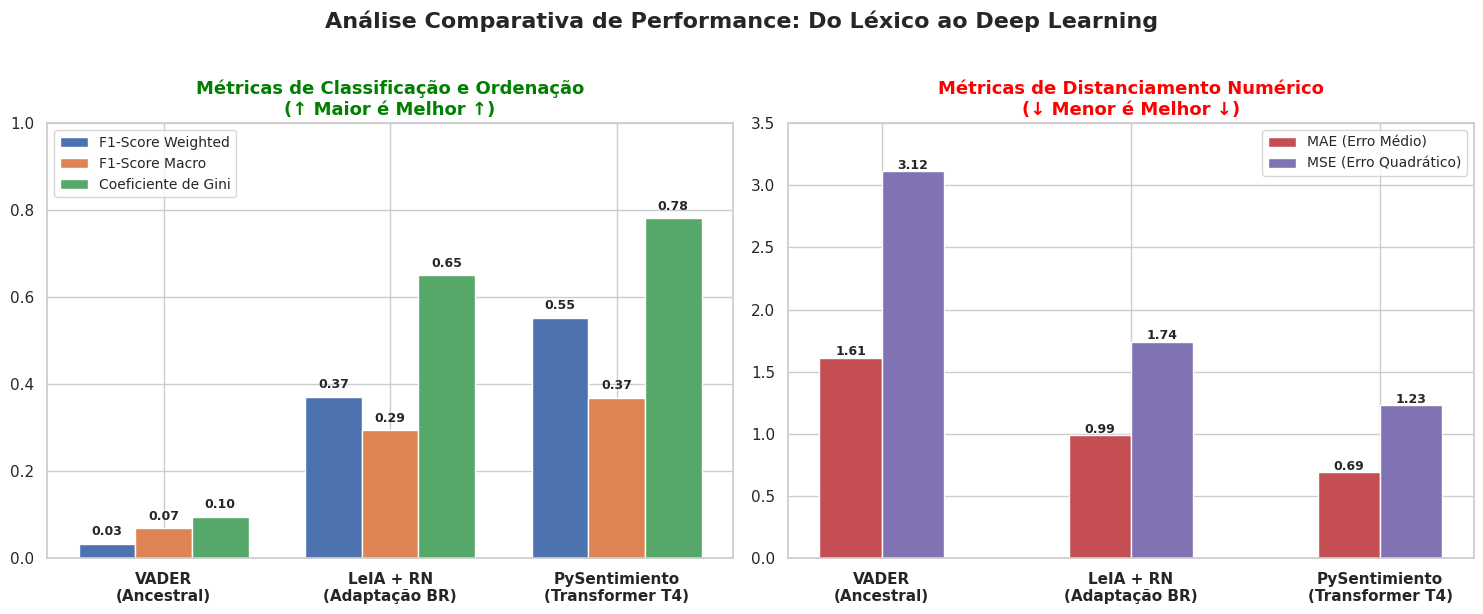

In [ ]:
# 1. Dados exatos extraídos do seu relatório (image_ca4c37.png)
modelos = ['VADER\n(Ancestral)', 'LeIA + RN\n(Adaptação BR)', 'PySentimiento\n(Transformer T4)']

# Agrupando as métricas por tipo (Scores vs Erros)
metricas_score = {
    'F1-Score Weighted': [0.034, 0.371, 0.552],
    'F1-Score Macro':    [0.069, 0.294, 0.369],
    'Coeficiente de Gini': [0.095, 0.650, 0.781]
}

metricas_erro = {
    'MAE (Erro em Estrelas)': [1.614, 0.989, 0.693],
    'MSE (Penalização)':      [3.115, 1.741, 1.232]
}

# 2. Configurando o layout com dois painéis lado a lado
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Análise Comparativa de Performance: Do Léxico ao Deep Learning', fontsize=16, weight='bold', y=1.02)

x = np.arange(len(modelos))  # Localização dos modelos
largura = 0.25               # Largura das barras

# --- PAINEL 1: MÉTRICAS DE ACERTO (SCORES) - QUANTO MAIOR, MELHOR ---
# Plotando F1-Weighted, F1-Macro e Gini
ax1.bar(x - largura, metricas_score['F1-Score Weighted'], largura, label='F1-Score Weighted', color='#4C72B0')
ax1.bar(x, metricas_score['F1-Score Macro'], largura, label='F1-Score Macro', color='#DD8452')
ax1.bar(x + largura, metricas_score['Coeficiente de Gini'], largura, label='Coeficiente de Gini', color='#55A868')

ax1.set_title('Métricas de Classificação e Ordenação\n(↑ Maior é Melhor ↑)', fontsize=13, weight='bold', color='green')
ax1.set_xticks(x)
ax1.set_xticklabels(modelos, weight='bold')
ax1.set_ylim(0, 1.0) # Escala fixa de 0 a 1 para scores
ax1.legend(loc='upper left', fontsize=10)

# Adicionando os valores em cima das barras (Data Labels) no Painel 1
for i, m in enumerate(metricas_score):
    valores = metricas_score[m]
    offset = (i - 1) * largura
    for j, val in enumerate(valores):
        ax1.text(j + offset, val + 0.02, f"{val:.2f}", ha='center', fontsize=9, weight='bold')

# --- PAINEL 2: MÉTRICAS DE ERRO - QUANTO MENOR, MELHOR ---
# Plotando MAE e MSE
ax2.bar(x - largura/2, metricas_erro['MAE (Erro em Estrelas)'], largura, label='MAE (Erro Médio)', color='#C44E52')
ax2.bar(x + largura/2, metricas_erro['MSE (Penalização)'], largura, label='MSE (Erro Quadrático)', color='#8172B3')

ax2.set_title('Métricas de Distanciamento Numérico\n(↓ Menor é Melhor ↓)', fontsize=13, weight='bold', color='red')
ax2.set_xticks(x)
ax2.set_xticklabels(modelos, weight='bold')
ax2.set_ylim(0, 3.5)
ax2.legend(loc='upper right', fontsize=10)

# Adicionando os valores em cima das barras (Data Labels) no Painel 2
for i, m in enumerate(metricas_erro):
    valores = metricas_erro[m]
    offset = (i - 0.5) * largura
    for j, val in enumerate(valores):
        ax2.text(j + offset, val + 0.02, f"{val:.2f}", ha='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

Os indicadores estatísticos consolidam a superioridade técnica do modelo PySentimiento (Transformer) em todas as dimensões avaliadas, superando os limites das abordagens léxicas (VADER e LeIA).

**Redução drástica do erro médio:** O modelo baseado em Transformer reduziu o Erro Médio Absoluto (MAE) para 0.693 estrelas, o que significa que, em média, as previsões do modelo flutuam a menos de uma estrela de distância da nota real do cliente. Da mesma forma, o menor MSE (1.232) confirma que o modelo minimiza outliers.

**Robustez de classificação e assertividade:** O F1-Score Weighted de 0.552 reflete uma sólida acurácia prática na operação corrente da base de dados. O recuo no F1-Score Macro (0.369) é esperado e formaliza o gargalo mapeado nas notas baixas (classes minoritárias).

**Alto poder de discriminação:** Por fim, o Coeficiente de Gini de 0.781 (contra os irrelevantes 0.095 do VADER e 0.650 do LeIA) valida cientificamente a alta sensibilidade e a capacidade do PySentimiento em separar, ordenar e distinguir com precisão os diferentes níveis de satisfação expressos pelos usuários.


---


In [ ]:
from scipy import stats

# 1. Definindo a sua régua de decisão (Nível de Significância)
alpha = 0.05

# 2. Calculando a Correlação de Pearson e o p-valor correspondente
r_pearson, p_valor = stats.pearsonr(df_s_comentario['nota_avaliacao'], df_s_comentario['nota_pysenti'])

print("======= TESTE DE HIPÓTESE (PEARSON) =======")
print(f"Coeficiente de Correlação (r): {r_pearson:.3f}")
print(f"p-valor calculado: {p_valor}")
print(f"Alvo / Nível Alpha: {alpha}")
print("-" * 43)

# 3. Tomada de decisão automatizada baseada no p-valor vs Alpha
if p_valor < alpha:
    print("REJEITAMOS A HIPÓTESE NULA (H0)!")
    print(f"Motivo: O p-valor ({p_valor}) é menor que o alpha ({alpha}).")
    print("Conclusão: A relação entre as notas reais e as previsões NÃO é fruto do acaso.")
    print("O modelo possui capacidade estatisticamente significante de predição.")
else:
    print("NÃO PODEMOS REJEITAR A HIPÓTESE NULA (H0).")
    print(f"Motivo: O p-valor ({p_valor}) é maior ou igual ao alpha ({alpha}).")
    print("Conclusão: Não há evidências estatísticas de que o modelo consiga prever as notas.")
    print("A correlação encontrada pode ser apenas ruído ou fruto do acaso.")

======= TESTE DE HIPÓTESE (PEARSON) =======
Coeficiente de Correlação (r): 0.759
p-valor calculado: 0.0
Alvo / Nível Alpha: 0.05
-------------------------------------------
REJEITAMOS A HIPÓTESE NULA (H0)!
Motivo: O p-valor (0.0) é menor que o alpha (0.05).
Conclusão: A relação entre as notas reais e as previsões NÃO é fruto do acaso.
O modelo possui capacidade estatisticamente significante de predição.


In [ ]:
# 1. Tamanho da amostra
print(f"n = {len(df_s_comentario)}")

# 2. O r que foi impresso (você provavelmente já tem, mas confirme)
print(f"r = {r_pearson:.6f}")

# 3. Forçar notação científica no p-valor
import numpy as np
print(f"p-valor em notação científica: {p_valor:.2e}")

# 4. Verificar se é literalmente 0.0 ou apenas muito pequeno
print(f"p-valor exato (repr): {repr(p_valor)}")